# ToTheMoon Diversified Investment Model

**Install libraries**

In [1]:
# STEP 1: Install necessary libraries
#!pip install scikit-learn pandas openpyxl matplotlib --quiet

**Import Packages**

In [2]:
# STEP 2: Import libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from datetime import timedelta
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
from google.colab import files
import datetime


**Take in user inputs**

In [3]:
# Input widgets for user-defined capital and investment horizon
import ipywidgets as widgets
from IPython.display import display

# Capital input (blank by default)
capital_input = widgets.FloatText(
    placeholder='Enter total capital',
    description='Capital ($):',
    disabled=False
)

# Start date input
start_date_input = widgets.Text(
    placeholder='YYYY-MM-DD',
    description='Start Date:',
    disabled=False
)

# End date input
end_date_input = widgets.Text(
    placeholder='YYYY-MM-DD',
    description='End Date:',
    disabled=False
)

# Display the input widgets
display(capital_input, start_date_input, end_date_input)


FloatText(value=0.0, description='Capital ($):')

Text(value='', description='Start Date:', placeholder='YYYY-MM-DD')

Text(value='', description='End Date:', placeholder='YYYY-MM-DD')

In [7]:
start_date = start_date_input.value  # e.g. '2025-01-01'
end_date = end_date_input.value      # e.g. '2025-02-28'
capital_input.value

10000.0

**Get weekly market data**

In [8]:
def get_market_data():

    # Get user input from widgets
    start = start_date_input.value
    end = end_date_input.value

    if not start:
        raise ValueError("❌ Please enter a valid start date.")
    if not end:
        end = datetime.datetime.today().strftime('%Y-%m-%d')

    # Backdate the start by 3 months for moving average comparisons
    start_dt = datetime.datetime.strptime(start, '%Y-%m-%d')
    padded_start_dt = start_dt - datetime.timedelta(weeks=12)
    padded_start = padded_start_dt.strftime('%Y-%m-%d')

    print(f"Fetching data from {padded_start} to {end} (includes buffer for MA comparisons)")

    # Fetch weekly data
    sp500 = yf.Ticker("^GSPC").history(start=padded_start, end=end, interval="1wk", auto_adjust=True)
    vix = yf.Ticker("^VIX").history(start=padded_start, end=end, interval="1wk", auto_adjust=True)

    if sp500.empty or vix.empty:
        raise ValueError("❌ Market data download failed.")

    sp500 = sp500.reset_index()
    vix = vix.reset_index()

    sp500["Date"] = pd.to_datetime(sp500["Date"]).dt.to_period("W").dt.start_time
    vix["Date"] = pd.to_datetime(vix["Date"]).dt.to_period("W").dt.start_time

    sp500 = sp500[["Date", "Close"]].rename(columns={"Close": "sp500_price"})
    vix = vix[["Date", "Close"]].rename(columns={"Close": "vix"})

    df = pd.merge(sp500, vix, on="Date", how="inner").rename(columns={"Date": "date"})
    df["sp500_return_1w"] = df["sp500_price"].pct_change()
    df["sp500_return_4w"] = df["sp500_price"].pct_change(periods=4)

    return df.reset_index(drop=True)


In [9]:
market_data = get_market_data()
market_data.head()
market_data.to_csv("market_data.csv", index=False)
#files.download("market_data.csv")


Fetching data from 2024-12-07 to 2025-03-31 (includes buffer for MA comparisons)


<ipython-input-8-598ced4a3980>:29: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  sp500["Date"] = pd.to_datetime(sp500["Date"]).dt.to_period("W").dt.start_time
<ipython-input-8-598ced4a3980>:30: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  vix["Date"] = pd.to_datetime(vix["Date"]).dt.to_period("W").dt.start_time


**Market condition assessment**

In [10]:
def assess_market_conditions(df, i):
    if i < 12:
        return "neutral"

    row = df.iloc[i]
    prev_4w = df.iloc[i-4:i]
    prev_12w = df.iloc[i-12:i]

    ma_4 = prev_4w["sp500_price"].mean()
    ma_12 = prev_12w["sp500_price"].mean()

    # Use .item() to convert Series scalar safely
    vix = row["vix"].item() if hasattr(row["vix"], "item") else row["vix"]
    r1w = row["sp500_return_1w"].item() if hasattr(row["sp500_return_1w"], "item") else row["sp500_return_1w"]
    r4w = row["sp500_return_4w"].item() if hasattr(row["sp500_return_4w"], "item") else row["sp500_return_4w"]

    bearish_signals = 0
    if vix > 25:
        bearish_signals += 1
    if r1w < -0.02 or r4w < -0.05:
        bearish_signals += 1
    if ma_4 < ma_12:
        bearish_signals += 1

    if bearish_signals >= 2:
        return "bearish"
    elif bearish_signals == 1:
        return "neutral"
    else:
        return "bullish"


**Deciding weekly allocation**

In [11]:
def decide_allocation(condition, vix=None):
    # Define base allocation ranges (tighter spread)
    base_alloc = {
        "bullish":  {"Growth": 0.45, "Blue Chip": 0.35, "Gold": 0.1,  "Cash": 0.1},
        "neutral":  {"Growth": 0.30, "Blue Chip": 0.35, "Gold": 0.2,  "Cash": 0.15},
        "bearish":  {"Growth": 0.20, "Blue Chip": 0.35, "Gold": 0.25, "Cash": 0.2}
    }

    alloc = base_alloc[condition].copy()

    # Apply light adjustments based on VIX
    if vix is not None:
        if vix > 30:
            # Move 5% from growth to cash, if safe to do so
            shift = 0.05
            if alloc["Growth"] >= shift:
                alloc["Growth"] -= shift
                alloc["Cash"] += shift
        elif vix < 15:
            # Move 2.5% from cash to growth
            shift = 0.025
            if alloc["Cash"] >= shift:
                alloc["Cash"] -= shift
                alloc["Growth"] += shift

    # Final check: ensure all weights still sum to 1.0 (float precision)
    total = sum(alloc.values())
    for k in alloc:
        alloc[k] = round(alloc[k] / total, 4)  # normalize and round

    return alloc


**Generating weekly allocations over time**

In [12]:
def generate_weekly_allocations(market_data_df):
    weekly_allocs = []

    for i in range(len(market_data_df)):
        try:
            condition = assess_market_conditions(market_data_df, i)
            vix = market_data_df.iloc[i]["vix"]
            allocation = decide_allocation(condition, vix=vix)
            allocation["date"] = market_data_df.iloc[i]["date"]
            allocation["condition"] = condition
            allocation["vix"] = vix
            weekly_allocs.append(allocation)
        except Exception as e:
            print(f"Skipped week {i}: {e}")

    return pd.DataFrame(weekly_allocs)


In [13]:
weekly_allocs = generate_weekly_allocations(market_data)


**Filtering by user defined range of dates**

In [14]:
def filter_allocations_by_user_range(weekly_allocs):
    import pandas as pd

    # Convert user input to datetime
    start_date = pd.to_datetime(start_date_input.value)
    end_date = pd.to_datetime(end_date_input.value)

    # Get the first allocation week that includes the start_date
    first_week = weekly_allocs[weekly_allocs['date'] <= start_date].tail(1)

    # Get all weeks after the start_date and within end_date
    rest_weeks = weekly_allocs[
        (weekly_allocs['date'] > start_date) &
        (weekly_allocs['date'] <= end_date)
    ]

    # Combine and reset index
    filtered = pd.concat([first_week, rest_weeks]).reset_index(drop=True)
    return filtered


In [15]:
filtered_allocs = filter_allocations_by_user_range(weekly_allocs)
filtered_allocs


,Growth,Blue Chip,Gold,Cash,date,condition,vix
0,0.3,0.35,0.20,0.15,2025-02-24,neutral,19.629999
1,0.3,0.35,0.20,0.15,2025-03-03,neutral,23.370001
2,0.2,0.35,0.25,0.20,2025-03-10,bearish,21.770000
3,0.2,0.35,0.25,0.20,2025-03-17,bearish,19.280001
4,0.2,0.35,0.25,0.20,2025-03-24,bearish,21.650000


# Blue Chip Stocks

**Blue Chip - First week conditions trading**

In [16]:
# Use first week of filtered allocation
first_week = filtered_allocs.iloc[0]

# Extract condition and VIX
condition = first_week["condition"]
vix = first_week["vix"]

# Run allocation logic
allocation = decide_allocation(condition, vix=vix)

# Get Blue Chip %
blue_chip_pct = allocation.get('Blue Chip', 0)

# Compute Blue Chip capital
blue_chip_capital = capital_input.value * blue_chip_pct
print(f"{first_week['date']} | Condition: {condition.upper()} | VIX: {vix}")
print(f"Blue Chip Allocation: {blue_chip_pct*100:.2f}% → ${blue_chip_capital:.2f}")



2025-02-24 00:00:00 | Condition: NEUTRAL | VIX: 19.6299991607666
Blue Chip Allocation: 35.00% → $3500.00


**Blue Chip - Technical Indicators**

In [17]:
def fetch_and_format_blue_chip_data(tickers, start, end):
    all_data = []

    for code, name in tickers.items():
        data = yf.download(code, start=start, end=end)
        if data.empty:
            continue
        data = data.reset_index()
        data['Name'] = name
        data['Type of stock'] = 'Blue Chip'
        data['Stock code'] = code
        data.rename(columns={'Adj Close': 'Close'}, inplace=True)
        all_data.append(data[['Name', 'Type of stock', 'Stock code', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume']])

    df = pd.concat(all_data, ignore_index=True)
    df = df.sort_values(by=['Stock code', 'Date'])
    return df


**Blue Chip - Retrieving stock data**

In [18]:
tickers = {
    'AAPL': 'Apple Inc',
    'AMGN': 'Amgen Inc',
    'AXP': 'American Express Co',
    'BA': 'Boeing Co',
    'CAT': 'Caterpillar Inc',
    'CVX': 'Chevron Corp',
    'CSCO': 'Cisco Systems',
    'DIS': 'Walt Disney Co',
    'GS': 'Goldman Sachs Group',
    'HON': 'Honeywell Int',
    'IBM': 'International Business Machines',
    'JPM': 'JPMorgan Chase',
    'JNJ': 'Johnson & Johnson',
    'KO': 'Coca-Cola Co',
    'MMM': '3M Company',
    'MCD': 'McDonald\'s Corp',
    'MSFT': 'Microsoft Corp',
    'MRK': 'Merck & Co',
    'NKE': 'Nike Inc',
    'PG': 'Procter & Gamble',
    'SHW': 'Sherwin-Williams',
    'TRV': 'Travelers Companies Inc',
    'UNH': 'UnitedHealth Group Inc',
    'VZ': 'Verizon Communications Inc',
    'V': 'Visa Inc',
    'WMT': 'Walmart Inc',
}

start_date = "2020-03-01"
end_date = datetime.datetime.today().strftime('%Y-%m-%d')

all_data = {}

for code, name in tickers.items():
    data = yf.download(code, start=start_date, end=end_date)
    if data.empty:
        continue
    data.index = pd.to_datetime(data.index)
    data = data.rename(columns={"Adj Close": "Close"})
    data["Stock code"] = code
    data["Name"] = name
    data["Type of stock"] = "blue chip"
    data = data[["Open", "High", "Low", "Close", "Volume", "Stock code", "Name", "Type of stock"]]
    all_data[code] = data


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [19]:
# Flatten columns in all_data dict (remove 'Ticker' MultiIndex level)
for ticker in all_data:
    df = all_data[ticker]
    df.columns = df.columns.get_level_values(-2)  # Keep only 'Open', 'High', etc.
    all_data[ticker] = df


**Blue Chip - Arranging data for analysis**

In [20]:
def build_long_form_df(all_data, tickers_dict):
    long_df_list = []

    for ticker, df_ticker in all_data.items():
        df_ticker = df_ticker.copy()
        df_ticker = df_ticker.reset_index()  # Make sure 'Date' is a column

        df_ticker["Stock code"] = ticker
        df_ticker["Name"] = tickers_dict[ticker]
        df_ticker["Type of stock"] = "Blue Chip"

        df_ticker = df_ticker[[
            "Name", "Type of stock", "Stock code", "Date",
            "Open", "High", "Low", "Close", "Volume"
        ]]

        long_df_list.append(df_ticker)

    combined_df = pd.concat(long_df_list, ignore_index=True)
    return combined_df

df = build_long_form_df(all_data, tickers)
df = df.iloc[:, 0:9]  # Keeps columns 0 to 8 (inclusive of 'Volume')


In [21]:
df

Price,Name,Type of stock,Stock code,Date,Open,High,Low,Close,Volume
0,Apple Inc,Blue Chip,AAPL,2020-03-02,68.503432,73.153162,67.396816,72.514915,341397200
1,Apple Inc,Blue Chip,AAPL,2020-03-03,73.694344,73.774425,69.357664,70.211899,319475600
2,Apple Inc,Blue Chip,AAPL,2020-03-04,71.939776,73.628820,71.136509,73.468651,219178400
3,Apple Inc,Blue Chip,AAPL,2020-03-05,71.716508,72.694504,70.719101,71.085548,187572800
4,Apple Inc,Blue Chip,AAPL,2020-03-06,68.435470,70.575900,68.248609,70.141502,226176800
...,...,...,...,...,...,...,...,...,...
33327,Walmart Inc,Blue Chip,WMT,2025-03-31,84.760002,88.199997,84.370003,87.790001,30269300
33328,Walmart Inc,Blue Chip,WMT,2025-04-01,87.540001,89.110001,87.370003,88.830002,22080300
33329,Walmart Inc,Blue Chip,WMT,2025-04-02,88.199997,90.150002,88.120003,89.760002,19384100
33330,Walmart Inc,Blue Chip,WMT,2025-04-03,86.279999,89.879997,86.279999,87.260002,33012900


**Blue Chip - Single stock plotting example**

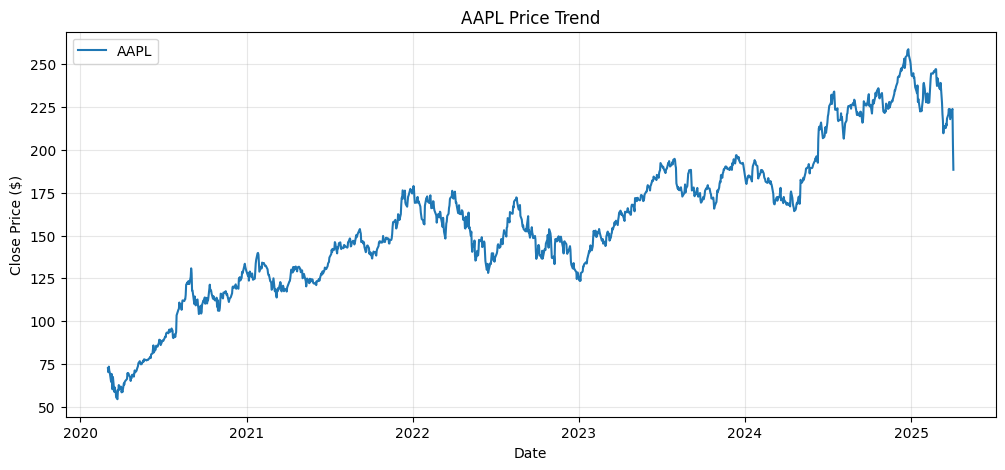

In [22]:
def plot_ticker(df, code='AAPL'):
    import matplotlib.pyplot as plt

    df_plot = df[df['Stock code'] == code]
    plt.figure(figsize=(12, 5))
    plt.plot(df_plot['Date'], df_plot['Close'], label=code)
    plt.title(f"{code} Price Trend")
    plt.xlabel("Date")
    plt.ylabel("Close Price ($)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


# Example: View Apple
plot_ticker(df, 'AAPL')


**Blue Chip - Adding features and technical indicators**

In [23]:
def add_features(group):
    group = group.sort_values(by='Date').copy()

    # All new columns are added safely
    group.loc[:, 'Return'] = group['Close'].pct_change(fill_method=None)
    group.loc[:, 'MA5'] = group['Close'].rolling(window=5).mean()
    group.loc[:, 'MA10'] = group['Close'].rolling(window=10).mean()
    group.loc[:, 'MA20'] = group['Close'].rolling(window=20).mean()
    group.loc[:, 'Volatility'] = group['Close'].rolling(window=10).std()
    group.loc[:, 'Volume_Change'] = group['Volume'].pct_change()

    group.loc[:, 'Future_Close'] = group['Close'].shift(-5)
    group.loc[:, 'Future_Return'] = (group['Future_Close'] - group['Close']) / group['Close']
    group.loc[:, 'Target'] = (group['Future_Return'] > 0).astype(int)

    return group


In [24]:
# Additional technical indicators
def add_technical_indicators(df):
    df = df.copy()

    # === RSI (Relative Strength Index, 14-period) ===
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # === MACD (12 EMA - 26 EMA) and Signal Line (9 EMA of MACD) ===
    ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_12 - ema_26
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

    # === Bollinger Bands (20-day MA ± 2 std dev) ===
    ma20 = df['Close'].rolling(window=20).mean()
    std20 = df['Close'].rolling(window=20).std()
    df['BB_upper'] = ma20 + 2 * std20
    df['BB_lower'] = ma20 - 2 * std20

    return df

**Blue Chip - Training model and feature selection**

<ipython-input-25-fbec84dfd8e4>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Stock code', group_keys=False).apply(add_features).reset_index(drop=True)
<ipython-input-25-fbec84dfd8e4>:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Stock code', group_keys=False).apply(add_technical_indicators).reset_index(drop=True)


Dataset after cleaning: 32838 rows
Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.52      0.53      1026
           1       0.50      0.51      0.51       946

    accuracy                           0.52      1972
   macro avg       0.52      0.52      0.52      1972
weighted avg       0.52      0.52      0.52      1972

Confusion Matrix:
 [[537 489]
 [459 487]]


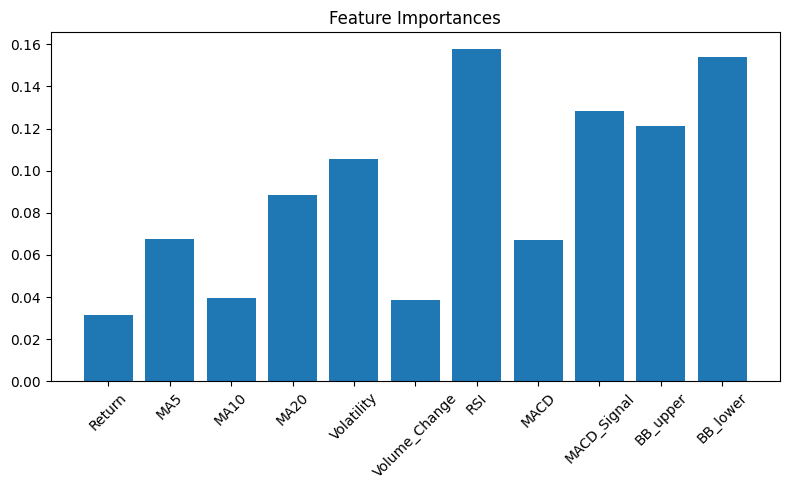

In [25]:
# Apply the function without including the group column
df = df.groupby('Stock code', group_keys=False).apply(add_features).reset_index(drop=True)
df = df.groupby('Stock code', group_keys=False).apply(add_technical_indicators).reset_index(drop=True)

# Drop rows with NaNs (only where required for model input)
required_cols = ['Return', 'MA5', 'MA10', 'MA20', 'Volatility', 'Volume_Change',
                 'RSI', 'MACD', 'MACD_Signal', 'BB_upper', 'BB_lower', 'Target']
df = df.dropna(subset=required_cols)

# Ensure we still have enough data
print(f"Dataset after cleaning: {len(df)} rows")

# STEP 6: Select features and target
features = ['Return', 'MA5', 'MA10', 'MA20', 'Volatility', 'Volume_Change',
            'RSI', 'MACD', 'MACD_Signal', 'BB_upper', 'BB_lower']

# Balance the classes (1:1 upsampling)
df_majority = df[df['Target'] == 1]
df_minority = df[df['Target'] == 0]
df_minority_upsampled = df_minority.sample(n=len(df_majority), replace=True, random_state=42)
df_balanced = pd.concat([df_majority, df_minority_upsampled])

# ✅ Sort by date to preserve time order
df_balanced = df_balanced.sort_values(by='Date').reset_index(drop=True)

# Manual time-aware split: 80% train, 20% test
# Make sure Date is datetime
df_balanced['Date'] = pd.to_datetime(df_balanced['Date'])

# Define custom date-based split
train_start = pd.to_datetime('2020-01-01')
train_end = pd.to_datetime('2024-12-16')
test_start = pd.to_datetime('2024-12-17')
test_end = pd.to_datetime('2025-03-30')

# Split
df_train = df_balanced[(df_balanced['Date'] >= train_start) & (df_balanced['Date'] <= train_end)]
df_test = df_balanced[(df_balanced['Date'] >= test_start) & (df_balanced['Date'] <= test_end)]

# Extract features and labels
X_train = df_train[features]
y_train = df_train['Target']
X_test = df_test[features]
y_test = df_test['Target']

# Attach metadata for simulation
X_test = X_test.copy()
X_test['Close'] = df_test['Close'].values
X_test['Date'] = pd.to_datetime(df_test['Date'])

##########################
#X_test['Date'] = pd.to_datetime(X_test['Date'], origin='1899-12-30', unit='D')
#print(X_test['Date'].min(), X_test['Date'].max())
#########################

X_test['Stock'] = df_test['Name'].values
X_test['Stock Code'] = df_test['Stock code'].values

# STEP 8: Train Gradient Boosting model
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# STEP 9: Evaluate model
y_pred = model.predict(X_test[features])
y_proba = model.predict_proba(X_test[features])[:, 1]

# Apply predictions back to full df
df['prediction'] = model.predict(df[features])
df['proba'] = model.predict_proba(df[features])[:, 1]

# Add prediction info to test set for simulation
X_test['prediction'] = y_pred
X_test['proba'] = y_proba

# === Evaluation output ===
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Feature Importance (optional)
importances = model.feature_importances_
plt.figure(figsize=(8, 5))
plt.bar(features, importances)
plt.title("Feature Importances")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [26]:
print("✅ Training ends:", df_train['Date'].max())
print("✅ Testing starts:", df_test['Date'].min())


✅ Training ends: 2024-12-16 00:00:00
✅ Testing starts: 2024-12-17 00:00:00


**Blue Chip - Backtest Function**

In [27]:
def blue_chip_backtest(
    X_test,
    confidence_threshold=0.50,
    take_profit=0.1,
    stop_loss=-0.05,
    holding_period=5,
    max_positions=7
):
    """
    Backtest using:
    - 8% minimum capital at 0.50 confidence
    - Linear allocation up to 0.60
    - Exponential scaling beyond 0.60
    - Cap of 30% max allocation
    - Fractional shares, capped exits, and trade limits
    """
    X_test = X_test.copy()
    X_test = X_test.sort_values(by='Date').reset_index(drop=True)

    cash = blue_chip_capital  # 🟢 Use capital from allocation logic
    active_trades = {}
    trade_log = []
    portfolio_history = []

    dates = X_test['Date'].unique()
    min_pct = 0.08
    max_pct = 0.30

    for current_date in dates:
        today_rows = X_test[X_test['Date'] == current_date]

        # === Release expired trades ===
        expired = [s for s, (sell_date, _, _, _) in active_trades.items() if sell_date <= current_date]
        for stock in expired:
            _, _, _, capital_allocated = active_trades[stock]
            cash += capital_allocated
            del active_trades[stock]

        # === Evaluate trade opportunities ===
        for _, row in today_rows.iterrows():
            stock = row['Stock']
            code = row.get('Stock Code', None)
            proba = row['proba']

            if stock in active_trades or len(active_trades) >= max_positions:
                continue
            if row['prediction'] == 1 and proba >= confidence_threshold:
                min_pct = 0.08
                mid_pct = 0.15
                max_pct = 0.30
                exp_power = 2.7

                if proba < 0.50:
                    continue
                elif proba <= 0.60:
                    score = (proba - 0.50) / (0.60 - 0.50)
                    capital_pct = min_pct + score * (mid_pct - min_pct)
                else:
                    score = ((proba - 0.60) / (1.00 - 0.60)) ** exp_power
                    capital_pct = mid_pct + score * (max_pct - mid_pct)

                capital_pct = max(0, min(1, capital_pct))
                capital_to_allocate = min(cash, blue_chip_capital * capital_pct)  # 🟢 use blue_chip_capital here

                if capital_to_allocate < blue_chip_capital * min_pct:  # 🟢 updated this too
                    continue

                buy_price = row['Close'] * 1.001 #add transaction fee of 0.1%
                shares = capital_to_allocate / buy_price

                # Get sell info after holding period
                stock_df = X_test[X_test['Stock'] == stock].sort_values(by='Date')
                future_rows = stock_df[stock_df['Date'] > current_date]
                if len(future_rows) < holding_period:
                    continue

                sell_row = future_rows.iloc[holding_period - 1]
                sell_price = sell_row['Close'] * 0.999 #subtract transaction fee of 0.1%
                sell_date = sell_row['Date']

                pct_return = (sell_price - buy_price) / buy_price
                pct_return = min(max(pct_return, stop_loss), take_profit)

                capped_sell_price = buy_price * (1 + pct_return)
                capped_revenue = shares * capped_sell_price
                actual_profit = capped_revenue - capital_to_allocate

                active_trades[stock] = (sell_date, buy_price, shares, capped_revenue)
                cash -= capital_to_allocate

                trade_log.append({
                    'Date': current_date,
                    'Sell Date': sell_date,
                    'Stock': stock,
                    'Stock Code': code,
                    'Buy Price': round(buy_price, 2),
                    'Sell Price': round(sell_price, 2),
                    'Confidence': round(proba, 4),
                    'Shares': round(shares, 4),
                    'Capital Allocated': round(capital_to_allocate, 2),
                    'Profit %': round(pct_return * 100, 2),
                    'Profit ($)': round(actual_profit, 2)
                })

        # === Track portfolio value ===
        active_value = sum(alloc for _, _, _, alloc in active_trades.values())
        total_portfolio = cash + active_value
        portfolio_history.append({
            'Date': current_date,
            'Portfolio_Value': total_portfolio
        })

    portfolio_df = pd.DataFrame(portfolio_history)
    trades_df = pd.DataFrame(trade_log)
    return portfolio_df, trades_df


**Blue Chip - Confidence Score table**

In [28]:
import pandas as pd

# Setup
confidence_levels = [0.50, 0.525, 0.55, 0.575, 0.60, 0.625, 0.65, 0.70, 0.75, 0.80, 0.90, 1.00]
initial_cash = blue_chip_capital

# Capital allocation thresholds
min_pct = 0.08   # 8% at 0.50
mid_pct = 0.15   # 15% at 0.60
max_pct = 0.30   # 30% at 1.00

# Desired minimal increase from 0.60 to 0.625
linear_step = (mid_pct - min_pct) / (0.60 - 0.50)  # = 0.07 / 0.10 = 0.7 per confidence
min_exp_jump = linear_step * 0.025  # 0.0175 (smallest step upward in exponential)

# Back-calculate the exponent needed
# We want: mid_pct + ((0.625 - 0.60)/0.4)^power * (max_pct - mid_pct) ≈ 0.15 + min_exp_jump
target_pct_at_625 = mid_pct + min_exp_jump  # ≈ 0.1675
target_score = (target_pct_at_625 - mid_pct) / (max_pct - mid_pct)
exp_input = (0.625 - 0.60) / (1.00 - 0.60)  # = 0.025 / 0.4 = 0.0625

# Solve for power: exp_input^power = target_score
import math
exp_power = math.log(target_score) / math.log(exp_input)

# Final power for exponential curve
exp_power = round(exp_power, 3)  # you can print this if curious

# Table calculation
data = []
for c in confidence_levels:
    if c < 0.50:
        capital_pct = 0.0
    elif c <= 0.60:
        score = (c - 0.50) / (0.60 - 0.50)
        capital_pct = min_pct + score * (mid_pct - min_pct)
    else:
        score = ((c - 0.60) / (1.00 - 0.60)) ** exp_power
        capital_pct = mid_pct + score * (max_pct - mid_pct)

    capital_pct = max(0, min(1, capital_pct))
    capital_invested = round(initial_cash * capital_pct, 2)
    percent_allocated = round(capital_pct * 100, 1)

    data.append({
        'Confidence': c,
        'Capital Invested ($)': capital_invested,
        '% of Capital': f"{percent_allocated}%",
        'Exponent': exp_power if c > 0.60 else 'Linear'
    })

investment_table = pd.DataFrame(data)
print("📊 Confidence-to-Capital Allocation Table (Smoothed Exponential Scaling):")
print(investment_table)


📊 Confidence-to-Capital Allocation Table (Smoothed Exponential Scaling):
    Confidence  Capital Invested ($) % of Capital Exponent
0        0.500                280.00         8.0%   Linear
1        0.525                341.25         9.8%   Linear
2        0.550                402.50        11.5%   Linear
3        0.575                463.75        13.2%   Linear
4        0.600                525.00        15.0%   Linear
5        0.625                586.23        16.7%    0.775
6        0.650                629.78        18.0%    0.775
7        0.700                704.29        20.1%    0.775
8        0.750                770.49        22.0%    0.775
9        0.800                831.80        23.8%    0.775
10       0.900                945.08        27.0%    0.775
11       1.000               1050.00        30.0%    0.775


**Blue Chip - Backtest Simulation**

In [29]:
# --- Setup ---
initial_capital = capital_input.value
remaining_cash = initial_capital
blue_chip_history = []
weekly_trades_log = []

# --- Loop through each week's allocation ---
for i, row in filtered_allocs.iterrows():
    week_start = row['date']
    condition = row['condition']
    vix = row['vix']

    # Recompute allocation for this week
    allocation = decide_allocation(condition, vix=vix)
    blue_chip_pct = allocation.get('Blue Chip', 0)

    # Compute Blue Chip capital for this week
    blue_chip_capital = remaining_cash * blue_chip_pct
    print(f"{week_start} | {condition.upper()} | VIX: {vix:.2f} → ${blue_chip_capital:.2f} to Blue Chip")

    # Pull a 6-week window of data for holding period simulation
    lookahead_weeks = 6
    cutoff_date = week_start + pd.Timedelta(weeks=lookahead_weeks)
    X_week = X_test[(X_test['Date'] >= week_start) & (X_test['Date'] < cutoff_date)].copy()

    if X_week.empty:
        print(f"⚠️ No trading data available for week starting {week_start}")
        continue

    # Run the blue chip backtest for this week
    try:
        portfolio_df, trades_df = blue_chip_backtest(X_week)
        final_value = portfolio_df['Portfolio_Value'].iloc[-1]

        # Add trade execution week for grouping later
        trades_df["Trade_Week"] = pd.to_datetime(trades_df["Date"]).dt.to_period("W").dt.start_time
        weekly_trades_log.append(trades_df)

        # Log summary stats
        blue_chip_history.append({
            'date': week_start,
            'capital_allocated': blue_chip_capital,
            'final_value': final_value,
            'net_gain': final_value - blue_chip_capital,
            'trades': len(trades_df)
        })

        # Update remaining cash
        remaining_cash += final_value - blue_chip_capital
    except Exception as e:
        print(f"❌ Error during trading on {week_start}: {e}")

# --- Combine all trades ---
all_trades_df = pd.concat(weekly_trades_log, ignore_index=True)

# Filter out trades after user's end date
end_date = pd.to_datetime(end_date_input.value)
all_trades_df = all_trades_df[pd.to_datetime(all_trades_df["Date"]) <= end_date]

# Calculate number of executed trades per actual Trade_Week
trade_counts = (
    all_trades_df
    .groupby("Trade_Week")
    .size()
    .reset_index(name="Number of Trades")
)

# Merge with blue_chip_results (aligning by week start date)
blue_chip_results = pd.DataFrame(blue_chip_history)
blue_chip_results = blue_chip_results.drop(columns=["trades"], errors="ignore")  # remove old column
blue_chip_results = blue_chip_results.merge(
    trade_counts,
    left_on="date",
    right_on="Trade_Week",
    how="left"
).drop(columns=["Trade_Week"])

# Fill missing with 0 trades (in case no trades executed that week)
blue_chip_results["Number of Trades"] = blue_chip_results["Number of Trades"].fillna(0).astype(int)

# Display final portfolio summary
display(blue_chip_results)


2025-02-24 00:00:00 | NEUTRAL | VIX: 19.63 → $3500.00 to Blue Chip
2025-03-03 00:00:00 | NEUTRAL | VIX: 23.37 → $3508.95 to Blue Chip
2025-03-10 00:00:00 | BEARISH | VIX: 21.77 → $3520.00 to Blue Chip
2025-03-17 00:00:00 | BEARISH | VIX: 19.28 → $3532.87 to Blue Chip
2025-03-24 00:00:00 | BEARISH | VIX: 21.65 → $3554.18 to Blue Chip


,date,capital_allocated,final_value,net_gain,Number of Trades
0,2025-02-24,3500.000000,3525.577851,25.577851,10
1,2025-03-03,3508.952248,3540.520585,31.568337,18
2,2025-03-10,3520.001166,3556.765830,36.764664,22
3,2025-03-17,3532.868798,3593.758244,60.889445,31
4,2025-03-24,3554.180104,3550.974028,-3.206076,19


**Blue Chip - Daily portfolio values**

,Date,Week,Condition,Total_Blue_Chip_Value
5,2025-03-01,2025-02-24,neutral,3517.78
6,2025-03-02,2025-02-24,neutral,3517.78
7,2025-03-03,2025-03-03,neutral,3512.77
8,2025-03-04,2025-03-03,neutral,3503.26
9,2025-03-05,2025-03-03,neutral,3519.90
10,2025-03-06,2025-03-03,neutral,3517.47
11,2025-03-07,2025-03-03,neutral,3515.11
12,2025-03-08,2025-03-03,neutral,3515.11
13,2025-03-09,2025-03-03,neutral,3515.11
14,2025-03-10,2025-03-10,bearish,3538.24


<ipython-input-30-119d491c3a35>:132: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


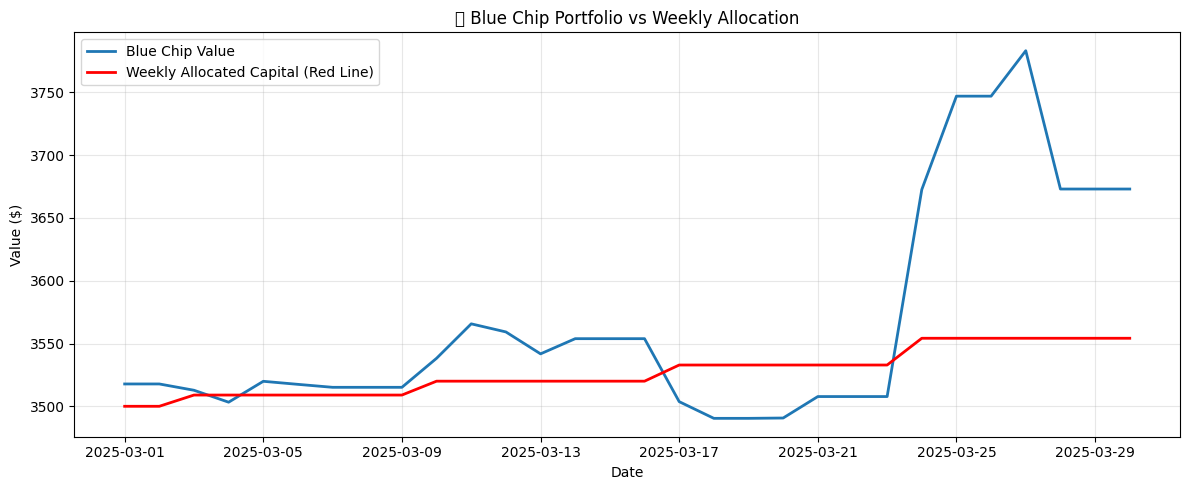

In [30]:
# ============================================
# PREP: COMBINE ALL BLUE CHIP TRADES INTO ONE DF
# ============================================

if 'weekly_trades_log' in globals():
    all_trades_df = pd.concat(weekly_trades_log, ignore_index=True)
else:
    raise ValueError("weekly_trades_log not found. Run your weekly backtest first.")

# ============================================
# BLUE CHIP DAILY VALUE TRACKING (USING day_revenue_bc FLOW LOGIC)
# ============================================

blue_chip_day_to_day = []

# Start and end dates
start_date = pd.to_datetime(start_date_input.value)
end_date = pd.to_datetime(end_date_input.value)

# Initialize with initial capital
current_total_portfolio_value = capital_input.value

# Build lookup for rebalancing targets
rebalance_lookup = blue_chip_results.set_index("date")["capital_allocated"].to_dict()

# Track ongoing value
day_revenue_bc = 0

# Iterate through each week in filtered_allocs
for i, row in filtered_allocs.iterrows():
    week_start = pd.to_datetime(row['date'])
    if week_start > end_date:
        break

    condition = row['condition']
    vix = row['vix']

    # Determine allocation %
    allocation = decide_allocation(condition, vix=vix)
    blue_chip_pct = allocation.get('Blue Chip', 0)

    # Get the rebalanced allocation from blue_chip_results (fallback to computed)
    allocated_to_blue_chip = rebalance_lookup.get(week_start, current_total_portfolio_value * blue_chip_pct)

    # Adjust cash based on rebalancing, but retain open positions' value
    day_revenue_bc = allocated_to_blue_chip

    # Generate daily values for this week
    week_dates = pd.date_range(start=week_start, periods=7, freq='D')
    for date in week_dates:
        if date > end_date:
            break

        # If any trades were sold today, add their profit/loss to day_revenue_bc
        closed_trades_today = all_trades_df[
            pd.to_datetime(all_trades_df['Sell Date']) == date
        ]
        if not closed_trades_today.empty:
            net_gain_today = closed_trades_today['Profit ($)'].sum()
            day_revenue_bc += net_gain_today

        blue_chip_day_to_day.append({
            'Date': date,
            'Week': week_start,
            'Condition': condition,
            'Total_Blue_Chip_Value': round(day_revenue_bc, 2)
        })

    # Set the new total portfolio value for next week's allocation
    current_total_portfolio_value = day_revenue_bc

# Convert to DataFrame
blue_chip_day_to_day_df = pd.DataFrame(blue_chip_day_to_day)

# Convert to DataFrame
blue_chip_day_to_day_df = pd.DataFrame(blue_chip_day_to_day)

# 🔥 Filter out early dates
blue_chip_day_to_day_df = blue_chip_day_to_day_df[blue_chip_day_to_day_df['Date'] >= start_date]

display(blue_chip_day_to_day_df)

# Plot
plt.figure(figsize=(12, 5))

# Plot the actual tracked daily portfolio value
plt.plot(
    blue_chip_day_to_day_df['Date'],
    blue_chip_day_to_day_df['Total_Blue_Chip_Value'],
    label='Blue Chip Value',
    linewidth=2
)

# 🧠 Build weekly allocation line from blue_chip_results
allocation_line = []
rebalance_lookup = blue_chip_results.set_index("date")["capital_allocated"].to_dict()

for week_start, allocation in rebalance_lookup.items():
    week_dates = pd.date_range(start=week_start, periods=7, freq='D')
    for date in week_dates:
        if date > end_date:
            break
        allocation_line.append({'Date': date, 'Weekly_Allocation_Value': allocation})

# Convert to DataFrame
allocation_df = pd.DataFrame(allocation_line)

# Merge to align on dates
combined_plot_df = pd.merge(
    blue_chip_day_to_day_df,
    allocation_df,
    on='Date',
    how='left'
).ffill()

# 🟥 Plot red solid line for actual weekly allocated capital
plt.plot(
    combined_plot_df['Date'],
    combined_plot_df['Weekly_Allocation_Value'],
    color='red',
    linestyle='-',
    linewidth=2,
    label='Weekly Allocated Capital (Red Line)'
)

# Final chart settings
plt.title('📈 Blue Chip Portfolio vs Weekly Allocation')
plt.xlabel('Date')
plt.ylabel('Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



**Blue Chip - First 5 trades of each week**

In [31]:
# ============================
# Show first 5 trades per week
# ============================

# Ensure 'Trade_Week' is datetime
all_trades_df["Trade_Week"] = pd.to_datetime(all_trades_df["Date"]).dt.to_period("W").dt.start_time

# Sort by week and confidence (or capital)
sorted_trades = all_trades_df.sort_values(by=["Trade_Week", "Confidence"], ascending=[True, False])

# Group and get first 5 per week
top_5_trades_per_week = (
    sorted_trades.groupby("Trade_Week")
    .head(5)
    .reset_index(drop=True)
)

# Display
print("📋 First 5 Trades Per Week (Sorted by Confidence):")
display(top_5_trades_per_week[[
    "Trade_Week", "Date", "Stock", "Confidence", "Capital Allocated", "Profit %", "Profit ($)"
]])


📋 First 5 Trades Per Week (Sorted by Confidence):


,Trade_Week,Date,Stock,Confidence,Capital Allocated,Profit %,Profit ($)
0,2025-02-24,2025-02-24,UnitedHealth Group Inc,0.6791,531.60,1.00,5.29
1,2025-02-24,2025-02-28,Amgen Inc,0.5989,522.34,2.56,13.36
2,2025-02-24,2025-02-28,Microsoft Corp,0.5273,347.00,0.81,2.82
3,2025-02-24,2025-02-24,Apple Inc,0.5250,341.19,-2.32,-7.93
4,2025-02-24,2025-02-24,Caterpillar Inc,0.5220,333.87,-2.23,-7.43
5,2025-03-03,2025-03-07,Boeing Co,0.6050,526.35,4.74,24.94
6,2025-03-03,2025-03-05,UnitedHealth Group Inc,0.6048,525.00,2.35,12.31
7,2025-03-03,2025-03-05,UnitedHealth Group Inc,0.6048,526.35,2.35,12.34
8,2025-03-03,2025-03-05,Amgen Inc,0.5989,522.34,0.53,2.78
9,2025-03-03,2025-03-03,Amgen Inc,0.5989,523.68,1.66,8.69


In [32]:
# ================================
# 📦 Optional: View All Trade Logs
# ================================
# Uncomment the line below to view all trades made during the simulation

#display(all_trades_df.head(10))


**Evaluation**

In [33]:
import numpy as np
import pandas as pd

def compute_performance_metrics(portfolio_df, trade_log, risk_free_rate=0.0):
    portfolio_df.index = pd.to_datetime(portfolio_df.index)

    # --- Annual Return ---
    initial_value = portfolio_df['Portfolio_Value'].iloc[0]
    final_value = portfolio_df['Portfolio_Value'].iloc[-1]
    total_days = (portfolio_df.index[-1] - portfolio_df.index[0]).days
    annual_return = (final_value / initial_value) ** (252 / total_days) - 1 if total_days > 0 else np.nan

    # --- Annual Volatility ---
    portfolio_df['Daily_Return'] = portfolio_df['Portfolio_Value'].pct_change()
    daily_volatility = portfolio_df['Daily_Return'].std()
    annual_volatility = daily_volatility * np.sqrt(252)

    # --- Sharpe Ratio ---
    sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility if annual_volatility != 0 else np.nan

    # --- Max Drawdown ---
    cum_max = portfolio_df['Portfolio_Value'].cummax()
    drawdown = (portfolio_df['Portfolio_Value'] - cum_max) / cum_max
    max_drawdown = drawdown.min()

    # --- Drawdown Events ---
    drawdown_events = 0
    peak = portfolio_df['Portfolio_Value'].iloc[0]
    for value in portfolio_df['Portfolio_Value']:
        if value > peak:
            peak = value
        elif (peak - value) / peak > 0:
            drawdown_events += 1

    # --- Trade Metrics ---
    num_trades = len(trade_log)
    if num_trades > 0:
        win_rate = (trade_log['Profit'] > 0).sum() / num_trades
        trade_log['Holding_Period'] = (trade_log['Exit_Date'] - trade_log['Entry_Date']).dt.days
        avg_holding_period = trade_log['Holding_Period'].mean()
        profit_per_trade = trade_log['Profit'].mean()
    else:
        win_rate = np.nan
        avg_holding_period = np.nan
        profit_per_trade = np.nan

    return {
        'Annual Return (%)': annual_return * 100,
        'Annual Volatility (%)': annual_volatility * 100,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown (%)': max_drawdown * 100,
        'Drawdown Events': drawdown_events,
        'Number of Trades': num_trades,
        'Win Rate (%)': win_rate * 100 if not np.isnan(win_rate) else np.nan,
        'Average Holding Period (days)': avg_holding_period,
        'Profit per Trade': profit_per_trade
    }


In [34]:
# ================================
# 🧮 Prepare Blue Chip Trade Log
# ================================

# Use existing trade log (already has profit and entry/exit info)
trade_log_df = pd.concat(weekly_trades_log, ignore_index=True)

# Rename columns to match what compute_performance_metrics expects
trade_log_df = trade_log_df.rename(columns={
    'Date': 'Entry_Date',
    'Sell Date': 'Exit_Date',
    'Buy Price': 'Entry_Price',
    'Sell Price': 'Exit_Price',
    'Profit ($)': 'Profit'
})

# Ensure datetime format
trade_log_df['Entry_Date'] = pd.to_datetime(trade_log_df['Entry_Date'])
trade_log_df['Exit_Date'] = pd.to_datetime(trade_log_df['Exit_Date'])

portfolio_df = blue_chip_day_to_day_df.copy()
portfolio_df.set_index('Date', inplace=True)
portfolio_df = portfolio_df[['Total_Blue_Chip_Value']].rename(columns={'Total_Blue_Chip_Value': 'Portfolio_Value'})

metrics = compute_performance_metrics(portfolio_df, trade_log_df)

metrics_df = pd.DataFrame(metrics.items(), columns=["Metric", "Value"])
metrics_df["Value"] = metrics_df["Value"].apply(lambda x: round(x, 2) if isinstance(x, float) else x)

print(metrics_df.to_string(index=False))


                       Metric  Value
            Annual Return (%)  45.54
        Annual Volatility (%)  18.74
                 Sharpe Ratio   2.43
             Max Drawdown (%)  -2.91
              Drawdown Events  21.00
             Number of Trades 100.00
                 Win Rate (%)  57.00
Average Holding Period (days)   5.96
             Profit per Trade   1.52


# Crypto & High-Growth stocks

**Growth - retrieving stock data**

In [35]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import yfinance as yf
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

# ======================
# 1. Data Preparation (Crypto + Stocks)
# ======================
crypto_tickers = ['BTC-USD', 'ETH-USD', 'XRP-USD']
stock_tickers = ['ABNB', 'AMZN', 'HD', 'LULU', 'TSLA',  # Consumer
                 'ISRG', 'LLY', 'MRNA', 'REGN', 'VRTX',  # Healthcare
                 'MCO', 'MELI', 'PYPL', 'SPGI', 'XYZ',   # Financials
                 'AMD', 'CRM', 'CRWD', 'MU', 'NVDA'] # Information Technologies

# Download Close Prices & Volume Data (2020-2025)
crypto_data = yf.download(crypto_tickers, start='2020-01-01', end='2025-04-30', progress=False)[['Close', 'Volume']]
stock_data = yf.download(stock_tickers, start='2020-01-01', end='2025-04-30', progress=False)[['Close', 'Volume']]

# Rename columns for clarity
crypto_close = crypto_data['Close'].rename(columns={'BTC-USD': 'BTC', 'ETH-USD': 'ETH', 'XRP-USD': 'XRP'})

# Rename stock columns
stock_close = stock_data['Close']

# Combine data into a single DataFrame
raw_data = pd.concat([crypto_close, stock_close,], axis=1).dropna()

# Make a copy for feature engineering
data = raw_data.copy()

# Save the DataFrame to a CSV file
#data.to_csv('crypto_and_stock_data.csv', index=True)

In [36]:
pip install ta

**Growth - Creating Features**

In [37]:
import pandas as pd
import numpy as np
import ta  # Using ta for technical indicators

def create_features(df):
    features = pd.DataFrame(index=df.index)

    # Price-based Features for All Assets
    for asset in df.columns:
        # **Lagged Returns**
        for lag in [1, 3, 7, 14]:
            features[f'{asset}_ret_{lag}d'] = df[asset].pct_change(lag)

        # **Volatility (21-day Rolling)**
        features[f'{asset}_vol_21d'] = df[asset].pct_change().rolling(21).std()

        # **Relative Strength Index (RSI)**
        features[f'{asset}_rsi'] = ta.momentum.RSIIndicator(df[asset], window=14).rsi()

        # **Simple & Exponential Moving Averages**
        features[f'{asset}_sma_50'] = df[asset].rolling(50).mean()
        features[f'{asset}_ema_20'] = df[asset].ewm(span=20).mean()

        # **Bollinger Bands (Upper & Lower)**
        bb = ta.volatility.BollingerBands(df[asset], window=20, window_dev=2)
        features[f'{asset}_bb_upper'] = bb.bollinger_hband()
        features[f'{asset}_bb_lower'] = bb.bollinger_lband()

        # **MACD (12, 26, 9)**
        macd = ta.trend.MACD(df[asset], window_slow=26, window_fast=12, window_sign=9)
        features[f'{asset}_macd'] = macd.macd()
        features[f'{asset}_macd_signal'] = macd.macd_signal()


    # **Cross-Asset Features (Ratios)**
    if 'BTC' in df.columns and 'ETH' in df.columns:
        features['BTC_ETH_ratio'] = df['BTC'] / df['ETH']
    if 'BTC' in df.columns and 'XRP' in df.columns:
        features['BTC_XRP_ratio'] = df['BTC'] / df['XRP']

    # **Sector-based Features (Averages)**
    tech_stocks = ['AMD', 'CRM', 'CRWD', 'MU', 'NVDA']
    healthcare_stocks = ['ISRG', 'LLY', 'MRNA', 'REGN', 'VRTX']
    financials_stocks = ['MCO', 'MELI', 'PYPL', 'SPGI']
    consumer_stocks = ['ABNB', 'AMZN', 'HD', 'LULU', 'TSLA']

    for sector, stocks in {'Tech': tech_stocks, 'Healthcare': healthcare_stocks,
                           'Financials': financials_stocks, 'Consumer': consumer_stocks}.items():
        available_stocks = [s for s in stocks if s in df.columns]
        if available_stocks:
            features[f'{sector}_avg'] = df[available_stocks].mean(axis=1)

    # **Drop NaN values**
    return features.dropna()

# Apply the feature engineering function
features = create_features(data)

**Growth - Training model**

In [38]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

# Define time periods
train_end = '2024-12-31'
val_start = '2025-01-01'
val_end = '2025-02-28'
test_start = '2024-12-16'
test_end = '2025-03-30'

import matplotlib.pyplot as plt
import seaborn as sns

def select_important_features(asset, features, price_data, importance_threshold=0.05):
    """Selects important features using a preliminary Random Forest model and plots the feature importance."""
    asset_features = [f"{asset}_ret_1d", f"{asset}_ret_3d", f"{asset}_ret_7d", f"{asset}_ret_14d",
                     f"{asset}_vol_21d", f"{asset}_rsi", f"{asset}_sma_50",
                     f"{asset}_ema_20", f"{asset}_bb_upper", f"{asset}_bb_lower",
                     f"{asset}_macd", f"{asset}_macd_signal"]

    # Add cross-asset/sector features (same as before)
    if asset == 'BTC':
        asset_features.extend(['BTC_ETH_ratio', 'BTC_XRP_ratio'])
    elif asset == 'ETH':
        asset_features.extend(['BTC_ETH_ratio'])
    elif asset in ['AMD', 'CRM', 'CRWD', 'MU', 'NVDA']:
        asset_features.append('Tech_avg')
    elif asset in ['ISRG', 'LLY', 'MRNA', 'REGN', 'VRTX']:
        asset_features.append('Healthcare_avg')
    elif asset in ['MCO', 'MELI', 'PYPL', 'SPGI', 'XYZ']:
        asset_features.append('Financials_avg')
    elif asset in ['ABNB', 'AMZN', 'HD', 'LULU', 'TSLA']:
        asset_features.append('Consumer_avg')

    # Create target variable
    target = price_data[asset].pct_change().shift(-4).rename('target')
    aligned_data = pd.concat([features[asset_features], target], axis=1).dropna()

    # Train Random Forest for feature selection
    model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    model.fit(aligned_data[asset_features], aligned_data['target'])

    # Get feature importance
    importance_df = pd.DataFrame({
        'Feature': asset_features,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)

    # Filter by threshold
    selected_features = importance_df[importance_df['Importance'] > importance_threshold]['Feature'].tolist()
    print(f"\nSelected features for {asset}: {selected_features}")

    # Plot feature importance
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=importance_df)
    plt.title(f'Feature Importance for {asset}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()

    return selected_features


# Dictionary to store MAE scores for each asset
mae_scores = {}

def train_predict(asset, features, price_data, selected_features):
    """
    Train model using only the selected features.
    """
    # Create target (Next 4 day's return)
    target = price_data[asset].pct_change().shift(-4).rename('target')

    # Combine selected features and target
    aligned_data = pd.concat([features[selected_features], target], axis=1).dropna()

    # Separate features (X) and target (y)
    X = aligned_data[selected_features]
    y = aligned_data['target']

    # Time-based masks
    dates = X.index
    train_mask = dates <= train_end
    test_mask = (dates >= test_start) & (dates <= test_end)

    # Split data
    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    # Train the final model
    final_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
    final_model.fit(X_train, y_train)

    # Evaluate Model
    # val_predictions = final_model.predict(X_val)
    # val_mae = mean_absolute_error(y_val, val_predictions)
    # print(f"Validation MAE: {val_mae:.4f}")

    test_predictions = final_model.predict(X_test)
    test_mae = mean_absolute_error(y_test, test_predictions)

    # Store MAE score
    mae_scores[asset] = test_mae  # Store MAE in the dictionary
    print(f"Test MAE: {test_mae:.4f}")


    return final_model, test_predictions

**Growth - Feature selection**

Processing BTC...

Selected features for BTC: ['BTC_vol_21d', 'BTC_ETH_ratio', 'BTC_XRP_ratio', 'BTC_ret_3d', 'BTC_ret_1d', 'BTC_ret_7d', 'BTC_ret_14d', 'BTC_macd']


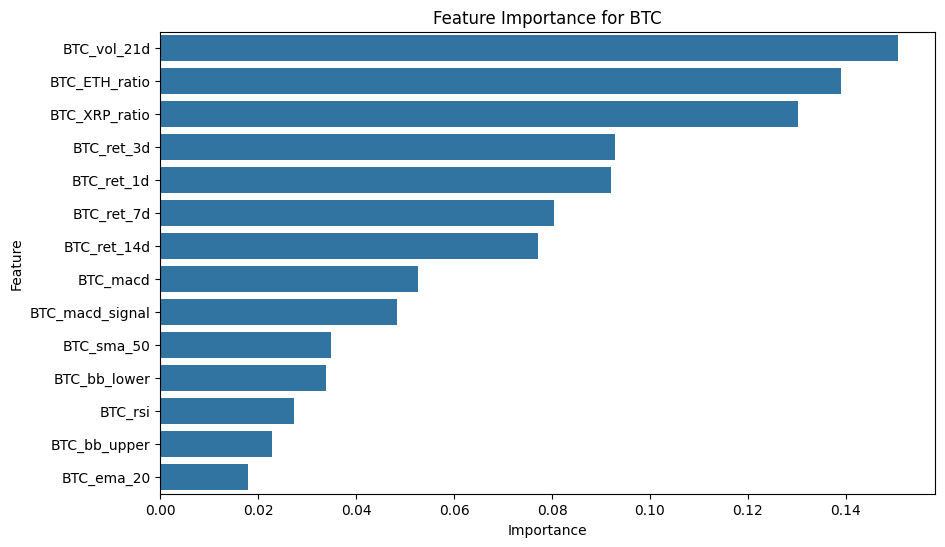

Test MAE: 0.0290


Processing ETH...

Selected features for ETH: ['ETH_macd', 'ETH_ret_7d', 'ETH_bb_upper', 'ETH_macd_signal', 'BTC_ETH_ratio', 'ETH_ret_14d', 'ETH_ret_3d', 'ETH_rsi', 'ETH_sma_50', 'ETH_bb_lower', 'ETH_vol_21d']


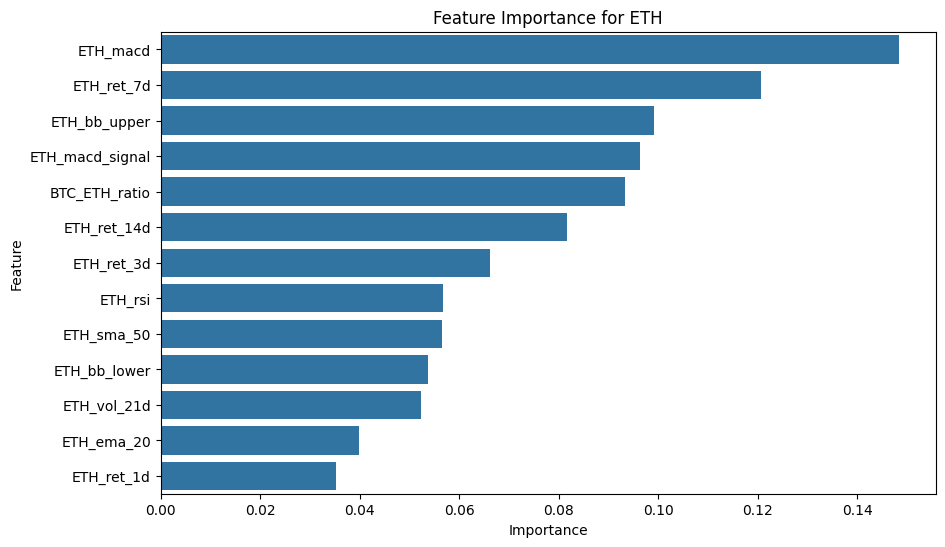

Test MAE: 0.0394


Processing XRP...

Selected features for XRP: ['XRP_rsi', 'XRP_ret_3d', 'XRP_vol_21d', 'XRP_ret_1d', 'XRP_ret_7d', 'XRP_bb_upper']


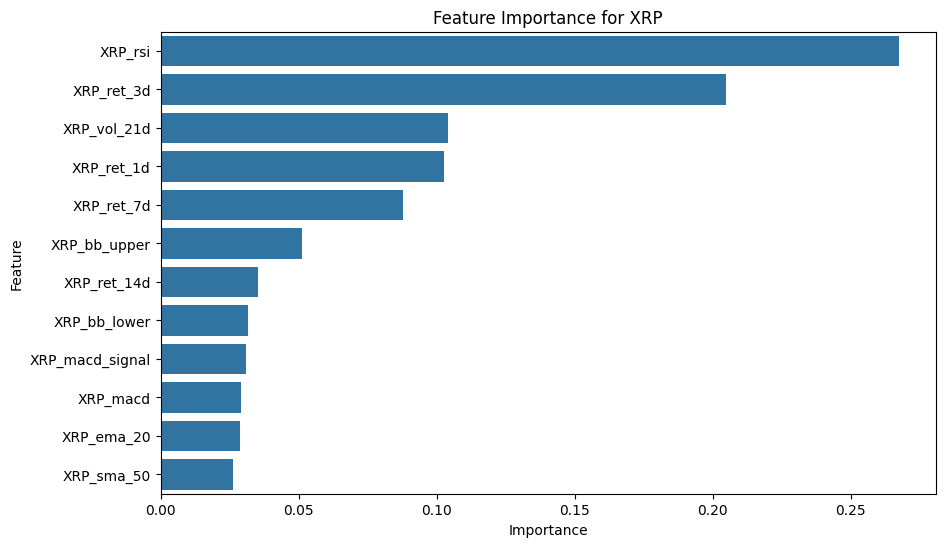

Test MAE: 0.0411


Processing ABNB...

Selected features for ABNB: ['ABNB_ret_14d', 'ABNB_ret_3d', 'ABNB_ret_7d', 'ABNB_bb_upper', 'ABNB_ret_1d', 'ABNB_vol_21d', 'ABNB_macd_signal', 'Consumer_avg', 'ABNB_rsi', 'ABNB_sma_50', 'ABNB_bb_lower', 'ABNB_ema_20', 'ABNB_macd']


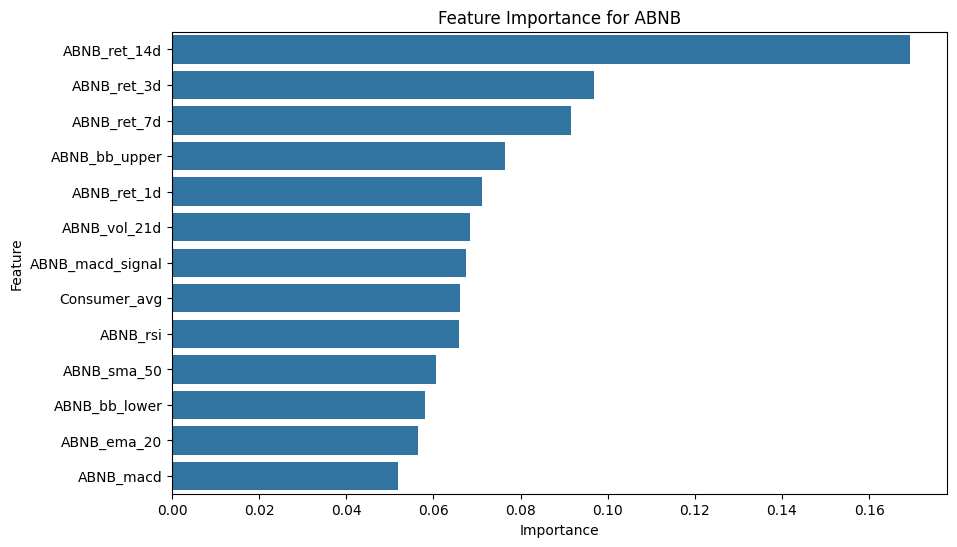

Test MAE: 0.0196


Processing AMD...

Selected features for AMD: ['AMD_vol_21d', 'AMD_bb_upper', 'AMD_rsi', 'AMD_ret_7d', 'AMD_ret_1d', 'AMD_ret_14d', 'AMD_ret_3d', 'AMD_macd', 'AMD_macd_signal', 'Tech_avg']


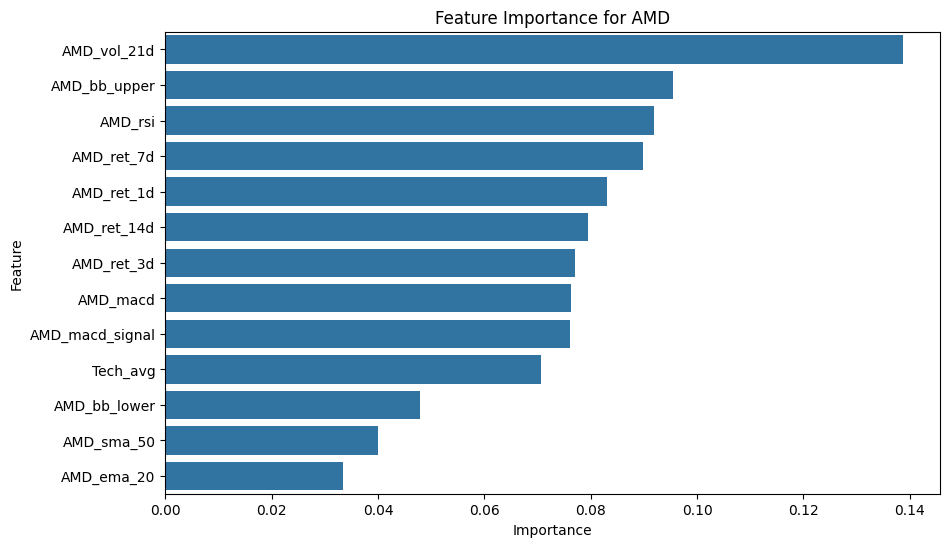

Test MAE: 0.0219


Processing AMZN...

Selected features for AMZN: ['AMZN_ret_1d', 'AMZN_ret_7d', 'AMZN_macd', 'Consumer_avg', 'AMZN_ret_14d', 'AMZN_macd_signal', 'AMZN_vol_21d', 'AMZN_ret_3d', 'AMZN_rsi']


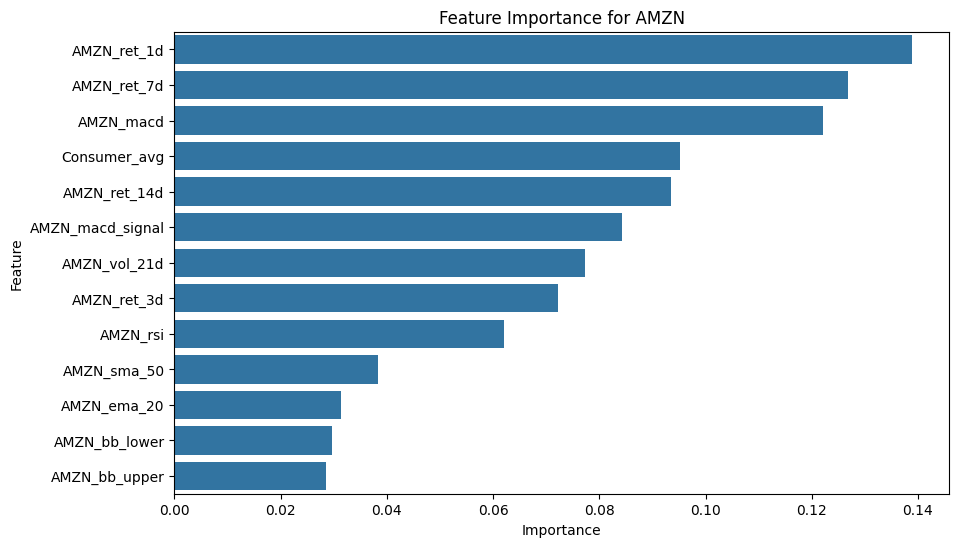

Test MAE: 0.0170


Processing CRM...

Selected features for CRM: ['CRM_sma_50', 'CRM_ret_3d', 'CRM_vol_21d', 'CRM_macd_signal', 'CRM_bb_upper', 'CRM_ret_1d', 'CRM_ret_7d', 'CRM_ret_14d', 'CRM_bb_lower']


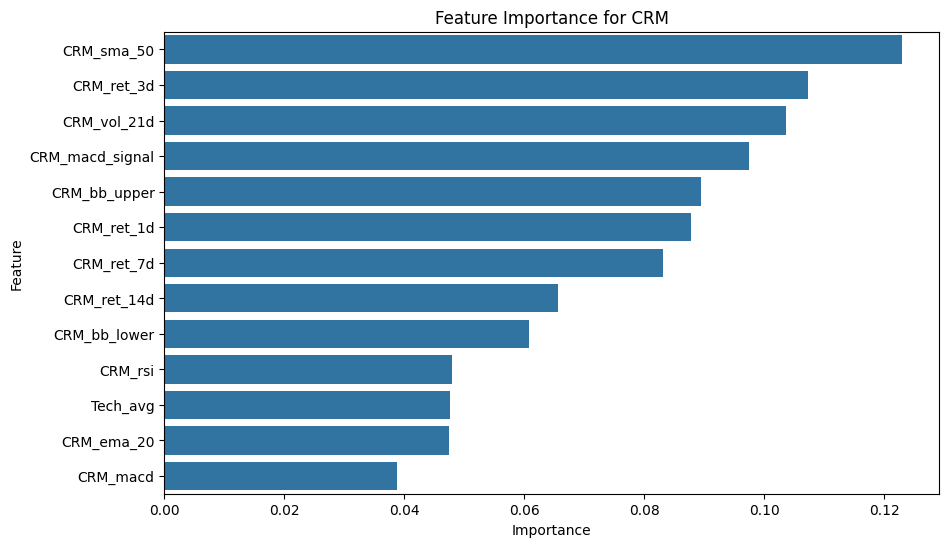

Test MAE: 0.0210


Processing CRWD...

Selected features for CRWD: ['CRWD_ret_3d', 'CRWD_bb_lower', 'CRWD_ret_1d', 'CRWD_vol_21d', 'CRWD_ret_7d', 'CRWD_macd_signal', 'CRWD_sma_50']


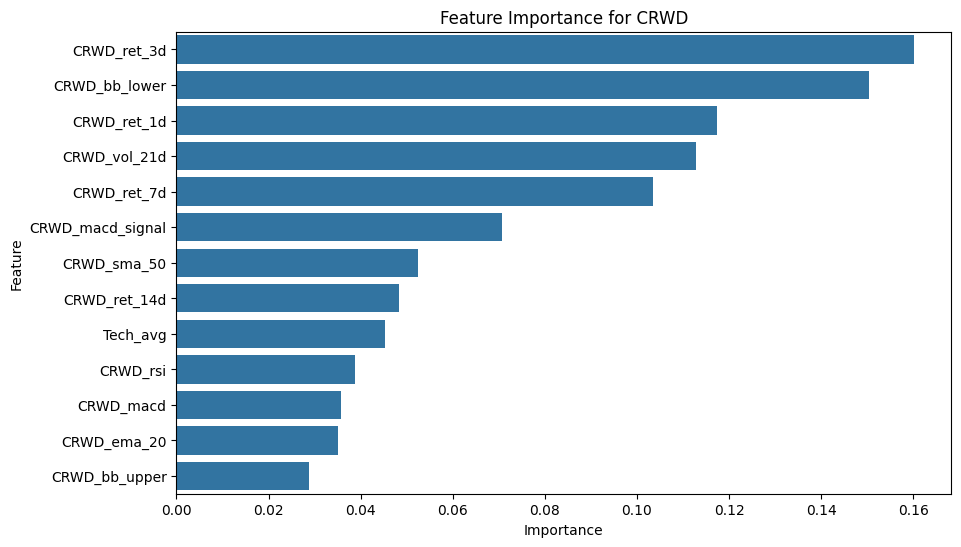

Test MAE: 0.0365


Processing HD...

Selected features for HD: ['HD_ret_1d', 'HD_ret_3d', 'HD_bb_lower', 'HD_ema_20', 'HD_vol_21d', 'HD_sma_50', 'HD_ret_7d', 'HD_ret_14d', 'HD_bb_upper', 'Consumer_avg', 'HD_rsi']


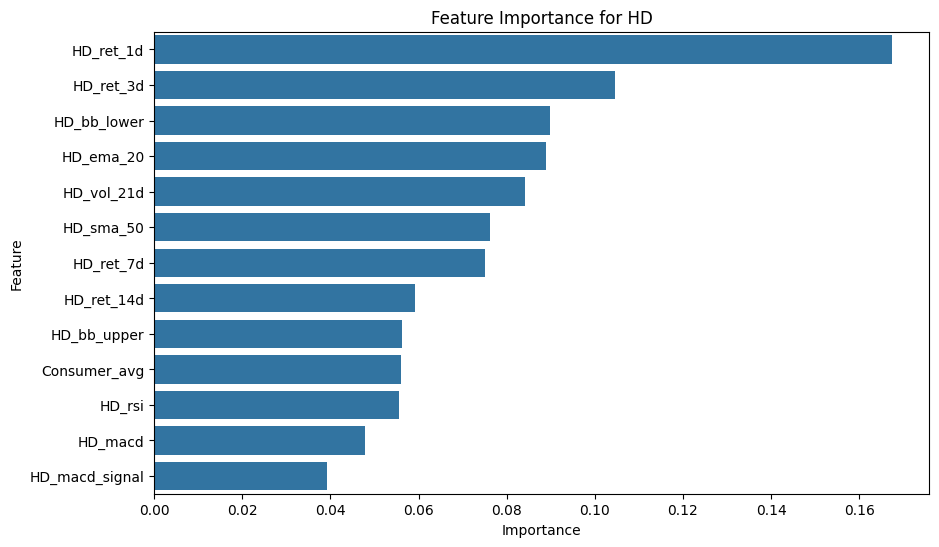

Test MAE: 0.0119


Processing ISRG...

Selected features for ISRG: ['ISRG_ret_14d', 'ISRG_ret_7d', 'ISRG_ret_3d', 'ISRG_sma_50', 'ISRG_ema_20', 'ISRG_bb_upper', 'ISRG_ret_1d', 'ISRG_vol_21d', 'ISRG_rsi', 'Healthcare_avg', 'ISRG_macd_signal', 'ISRG_macd']


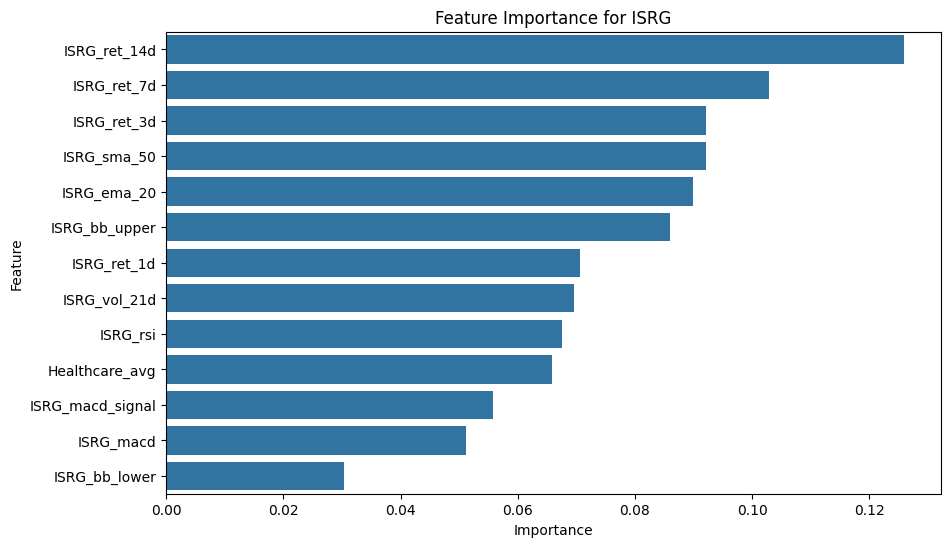

Test MAE: 0.0157


Processing LLY...

Selected features for LLY: ['LLY_ret_3d', 'LLY_ret_14d', 'LLY_vol_21d', 'Healthcare_avg', 'LLY_bb_lower', 'LLY_ret_1d', 'LLY_ret_7d', 'LLY_macd', 'LLY_macd_signal', 'LLY_rsi']


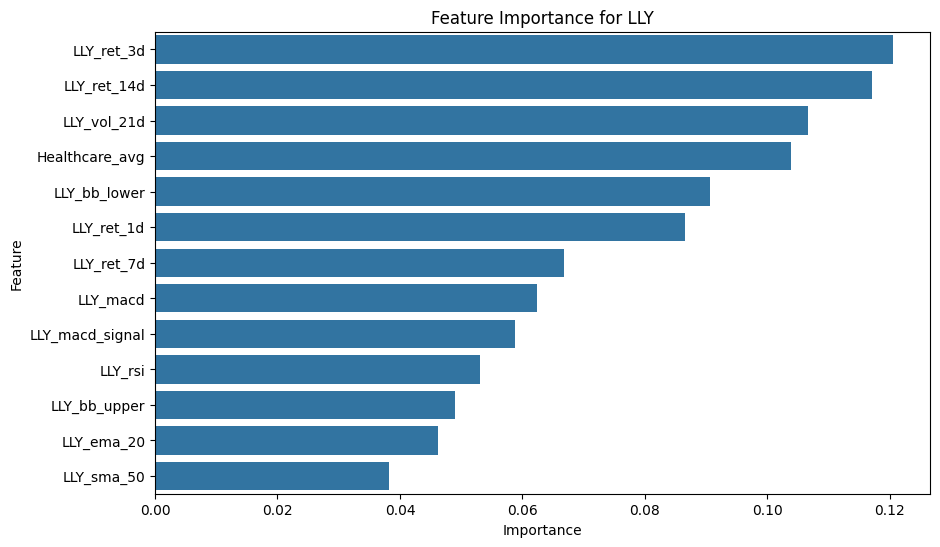

Test MAE: 0.0158


Processing LULU...

Selected features for LULU: ['Consumer_avg', 'LULU_ret_1d', 'LULU_ret_7d', 'LULU_ret_3d', 'LULU_macd', 'LULU_sma_50', 'LULU_rsi', 'LULU_ema_20', 'LULU_bb_lower', 'LULU_vol_21d', 'LULU_ret_14d']


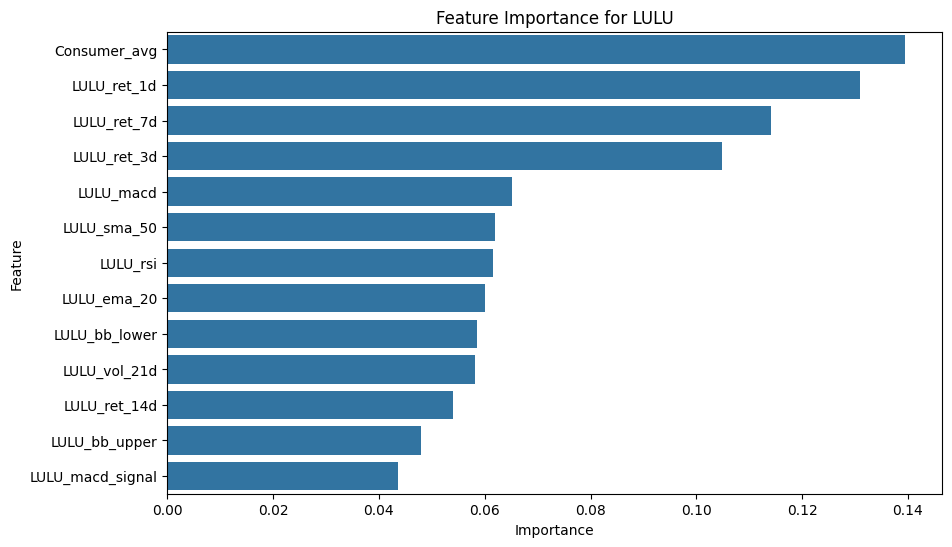

Test MAE: 0.0183


Processing MCO...

Selected features for MCO: ['MCO_sma_50', 'MCO_bb_upper', 'Financials_avg', 'MCO_bb_lower', 'MCO_ret_3d', 'MCO_ema_20', 'MCO_vol_21d', 'MCO_ret_14d', 'MCO_ret_1d', 'MCO_ret_7d']


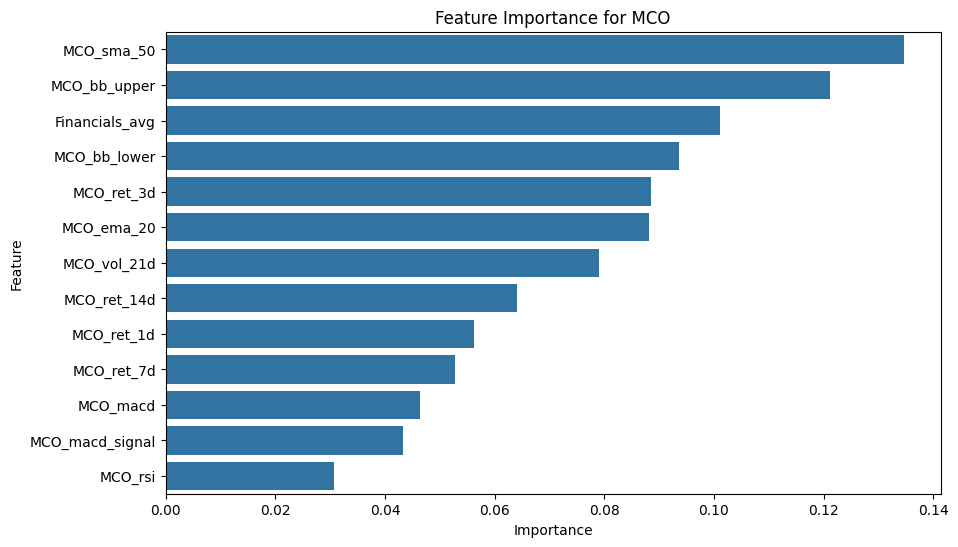

Test MAE: 0.0123


Processing MELI...

Selected features for MELI: ['MELI_ret_1d', 'MELI_vol_21d', 'MELI_ret_3d', 'MELI_ret_7d', 'MELI_sma_50', 'MELI_ret_14d', 'MELI_bb_lower', 'MELI_ema_20', 'Financials_avg']


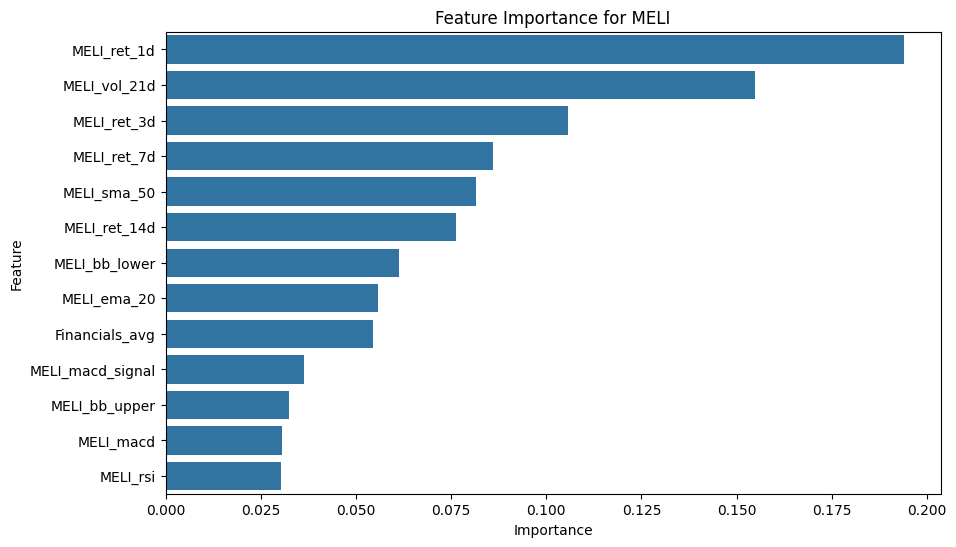

Test MAE: 0.0186


Processing MRNA...

Selected features for MRNA: ['MRNA_macd_signal', 'MRNA_vol_21d', 'MRNA_ret_14d', 'Healthcare_avg', 'MRNA_sma_50', 'MRNA_ret_1d', 'MRNA_ret_7d', 'MRNA_bb_lower', 'MRNA_ret_3d', 'MRNA_rsi', 'MRNA_macd']


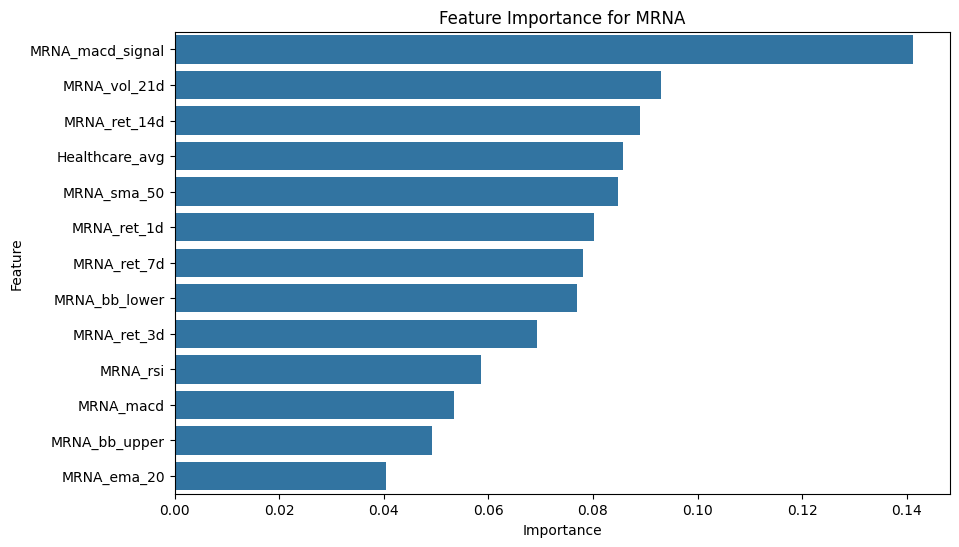

Test MAE: 0.0641


Processing MU...

Selected features for MU: ['MU_ret_7d', 'MU_ret_14d', 'MU_vol_21d', 'MU_sma_50', 'Tech_avg', 'MU_bb_upper', 'MU_ret_3d', 'MU_ret_1d']


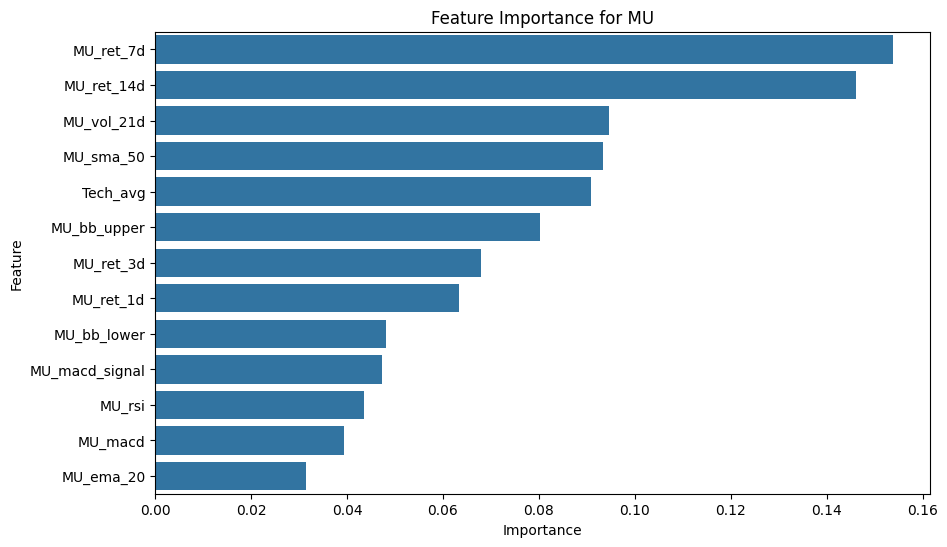

Test MAE: 0.0295


Processing NVDA...

Selected features for NVDA: ['NVDA_ret_3d', 'NVDA_bb_lower', 'NVDA_ret_1d', 'NVDA_rsi', 'NVDA_ret_14d', 'NVDA_vol_21d', 'NVDA_macd', 'NVDA_ret_7d', 'NVDA_macd_signal', 'Tech_avg']


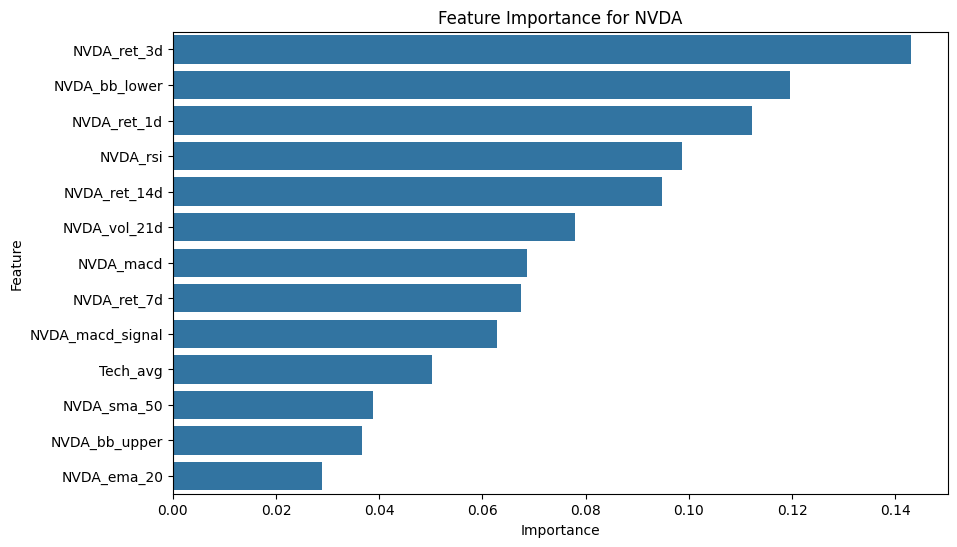

Test MAE: 0.0321


Processing PYPL...

Selected features for PYPL: ['PYPL_ret_3d', 'PYPL_vol_21d', 'Financials_avg', 'PYPL_ret_14d', 'PYPL_ret_7d', 'PYPL_macd_signal', 'PYPL_rsi', 'PYPL_ret_1d', 'PYPL_bb_lower']


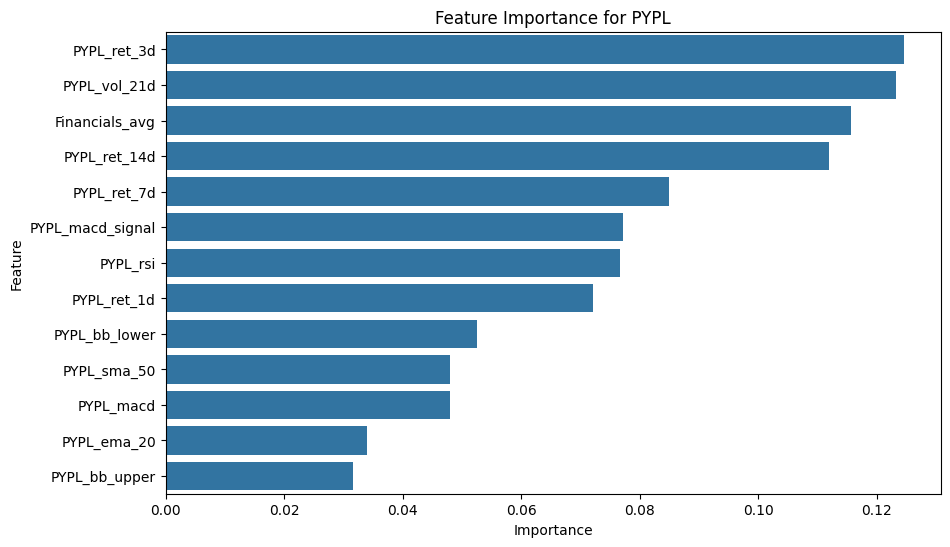

Test MAE: 0.0180


Processing REGN...

Selected features for REGN: ['REGN_ret_1d', 'REGN_bb_lower', 'REGN_ema_20', 'Healthcare_avg', 'REGN_vol_21d', 'REGN_ret_14d', 'REGN_macd_signal', 'REGN_ret_7d', 'REGN_ret_3d', 'REGN_sma_50', 'REGN_bb_upper', 'REGN_rsi']


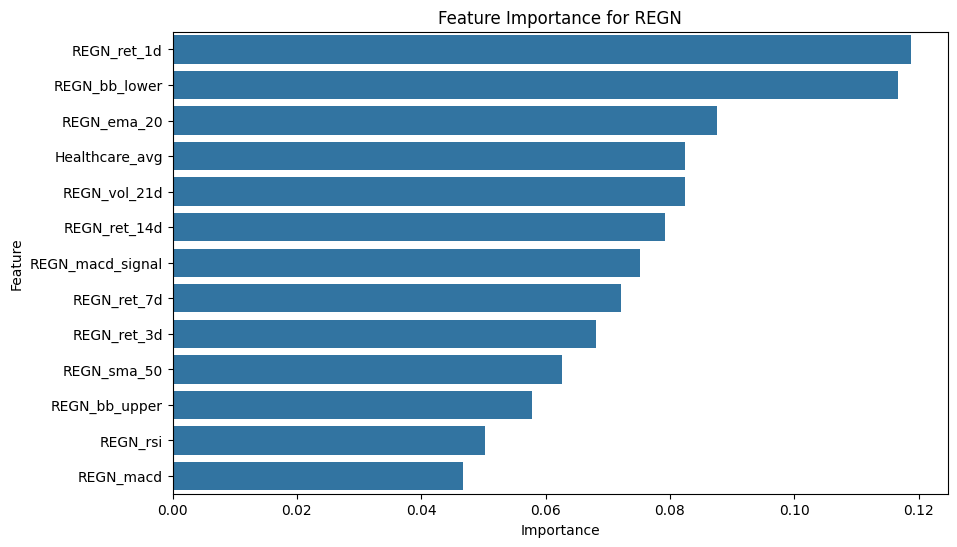

Test MAE: 0.0159


Processing SPGI...

Selected features for SPGI: ['SPGI_sma_50', 'SPGI_ret_1d', 'SPGI_bb_lower', 'Financials_avg', 'SPGI_macd_signal', 'SPGI_ret_3d', 'SPGI_macd', 'SPGI_ema_20', 'SPGI_ret_14d', 'SPGI_bb_upper']


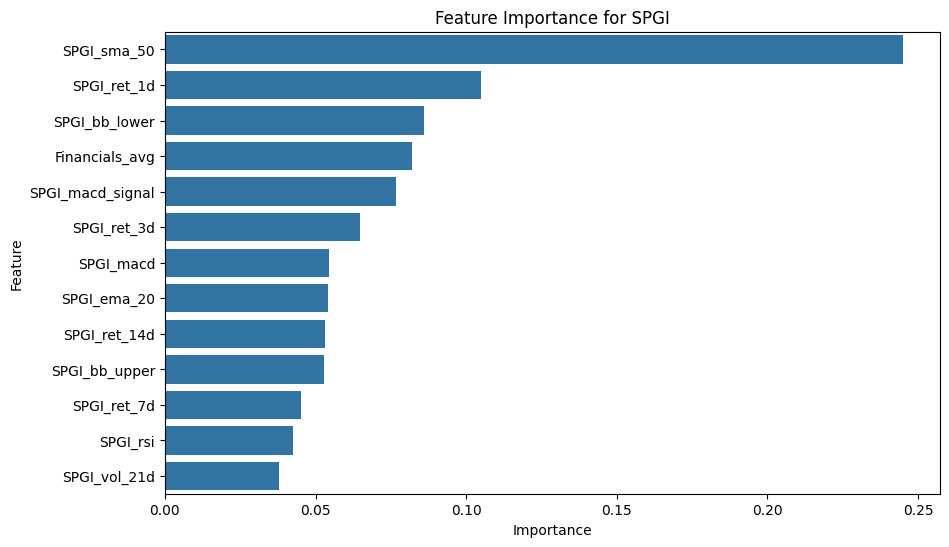

Test MAE: 0.0101


Processing TSLA...

Selected features for TSLA: ['TSLA_ret_7d', 'TSLA_ret_14d', 'TSLA_vol_21d', 'TSLA_ema_20', 'TSLA_macd_signal', 'TSLA_ret_3d', 'TSLA_rsi', 'TSLA_bb_upper', 'TSLA_ret_1d', 'TSLA_sma_50', 'TSLA_macd']


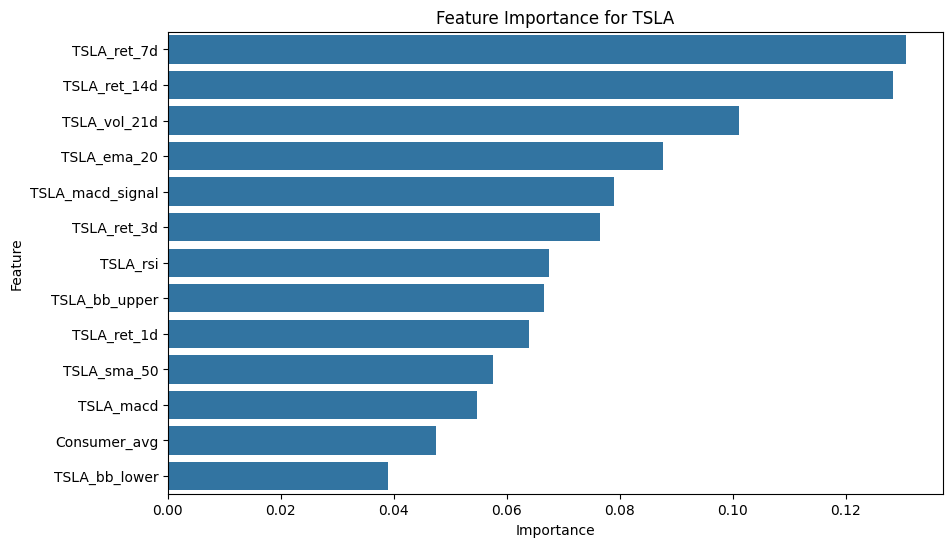

Test MAE: 0.0326


Processing VRTX...

Selected features for VRTX: ['VRTX_ret_1d', 'VRTX_macd_signal', 'VRTX_ret_3d', 'VRTX_sma_50', 'VRTX_ret_14d', 'VRTX_ema_20', 'VRTX_vol_21d', 'VRTX_macd', 'VRTX_bb_upper']


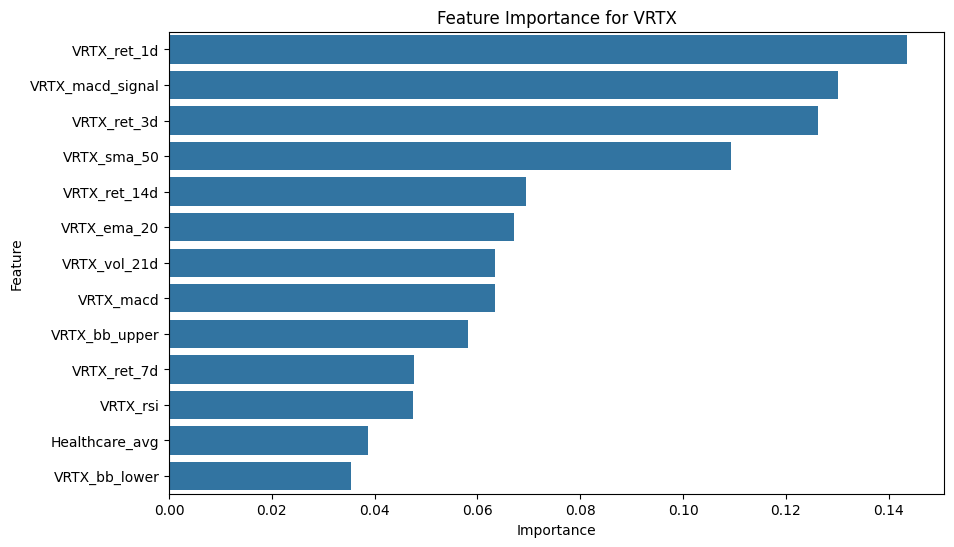

Test MAE: 0.0118


Processing XYZ...

Selected features for XYZ: ['XYZ_ret_1d', 'XYZ_ret_3d', 'Financials_avg', 'XYZ_ret_7d', 'XYZ_vol_21d', 'XYZ_macd_signal', 'XYZ_macd', 'XYZ_ret_14d', 'XYZ_ema_20']


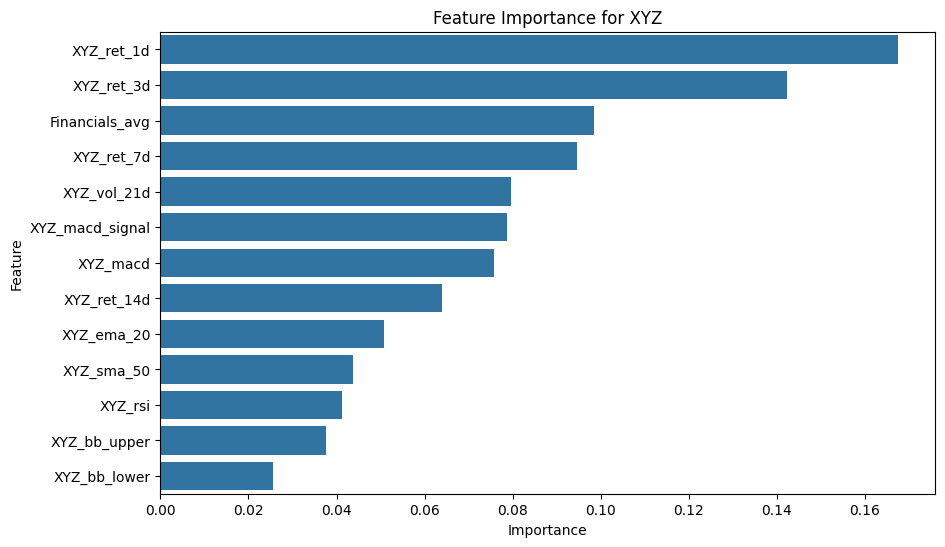

Test MAE: 0.0276




In [39]:
# ======================
# 3. Generate Signals with Test Isolation
# ======================
# Define test period
# Create test_dates from start to end
test_dates = data.loc[test_start:test_end].index

# Initialize predictions DataFrame with the filtered test dates
predictions = pd.DataFrame(index=test_dates)

# Iterate over each asset
for asset in data.columns:
    print(f"Processing {asset}...")

    # Step 1: Select Important Features
    selected_features = select_important_features(asset, features, data, importance_threshold=0.05)

    # Step 2: Train Model Using Selected Features
    best_model, test_predictions = train_predict(asset, features, data, selected_features)

    # Wrap predictions in a Series using matching portion of test_dates
    test_predictions_series = pd.Series(test_predictions, index=test_dates[:len(test_predictions)])

    # Store aligned predictions
    predictions[f'{asset}_pred'] = test_predictions_series.reindex(test_dates)


    print("\n")


**Growth - plotting example for trading model**

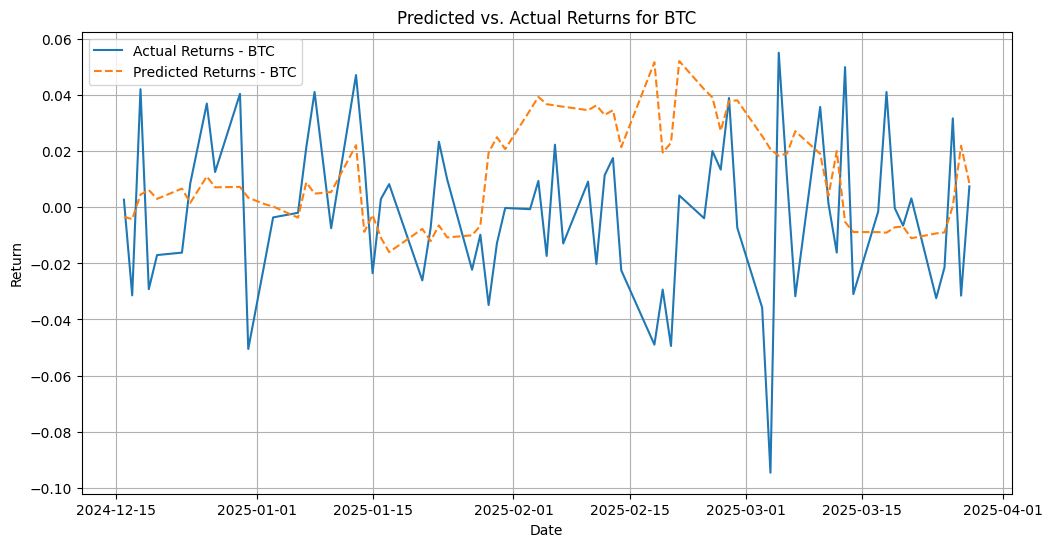

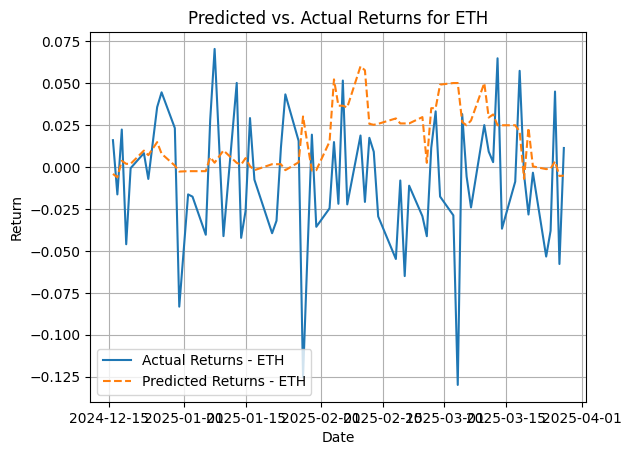

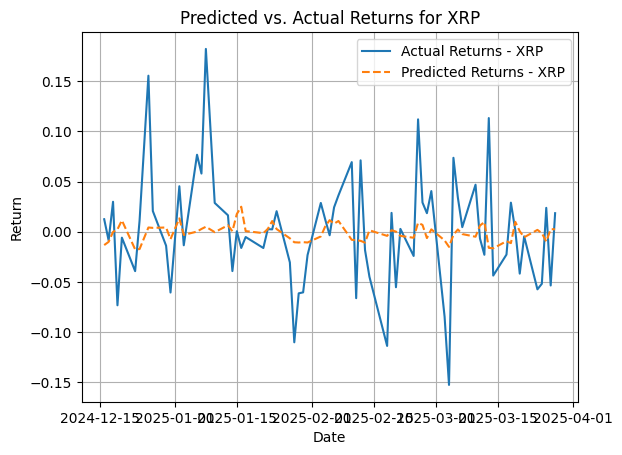

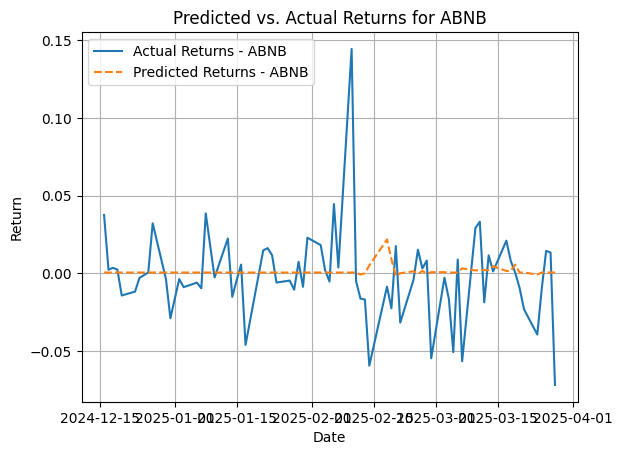

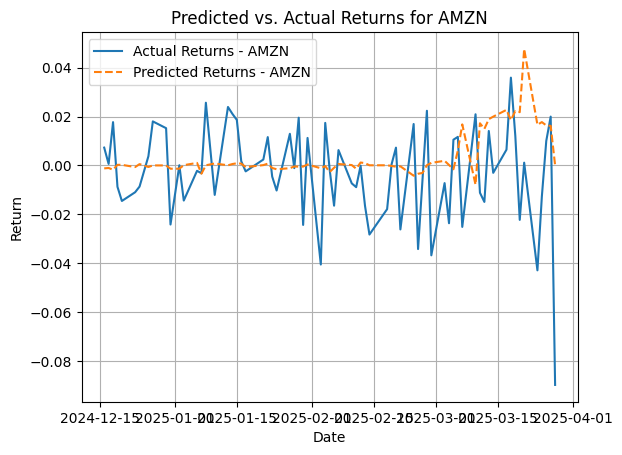

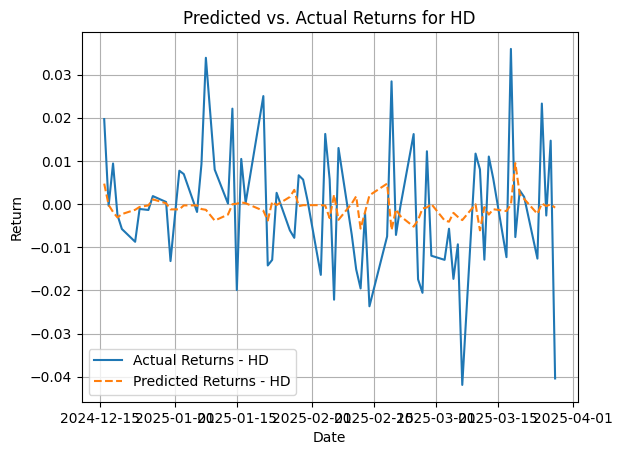

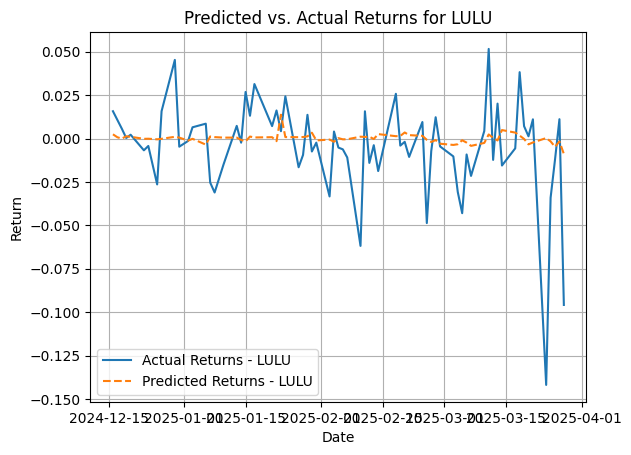

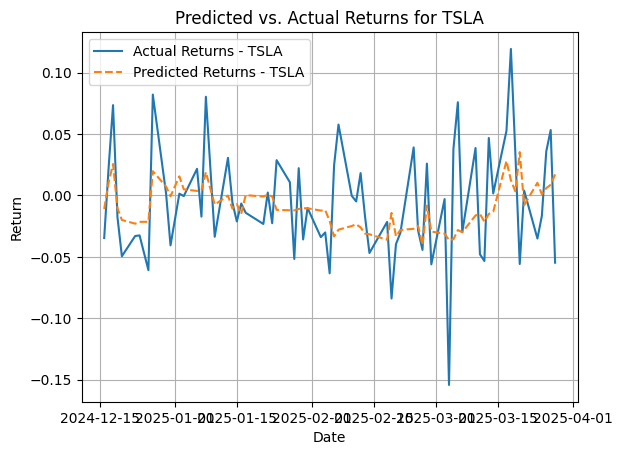

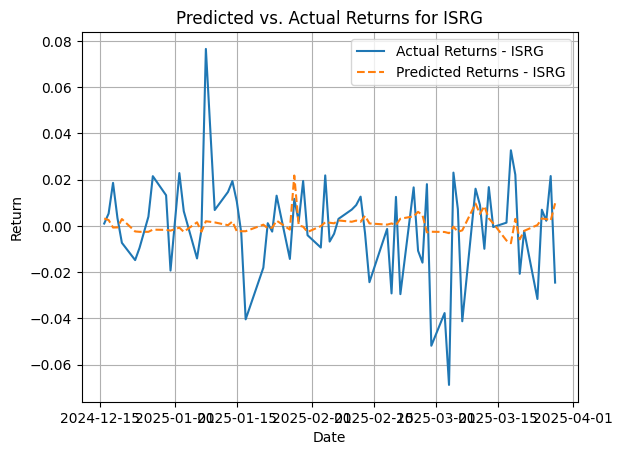

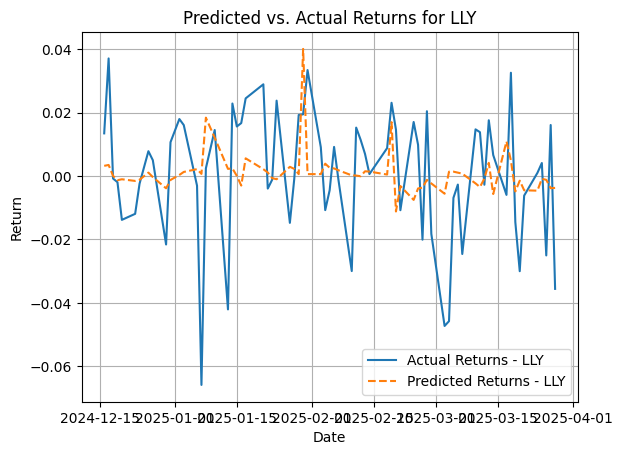

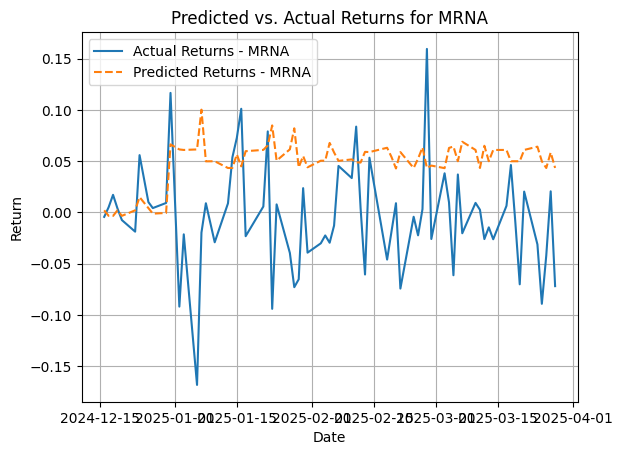

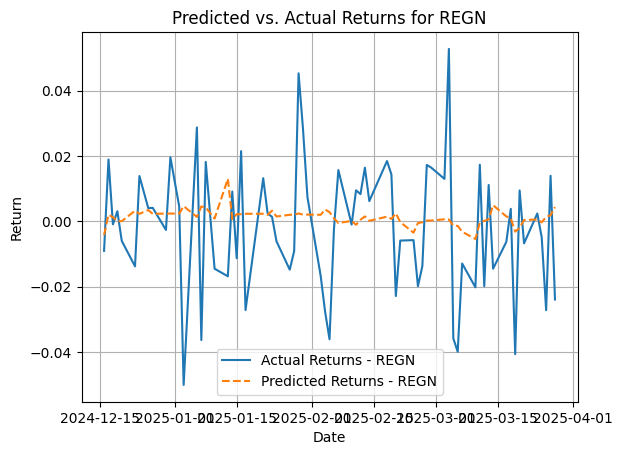

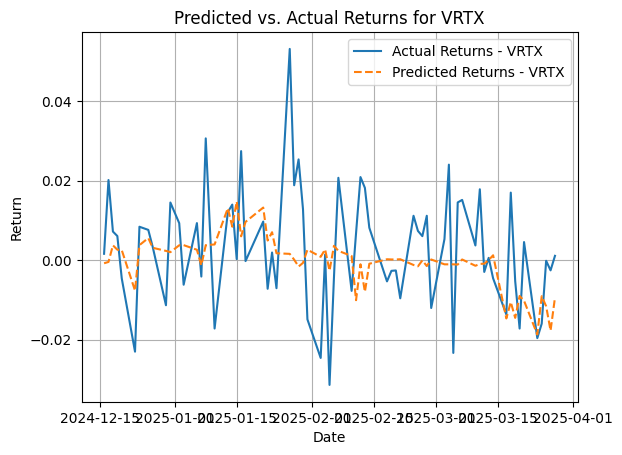

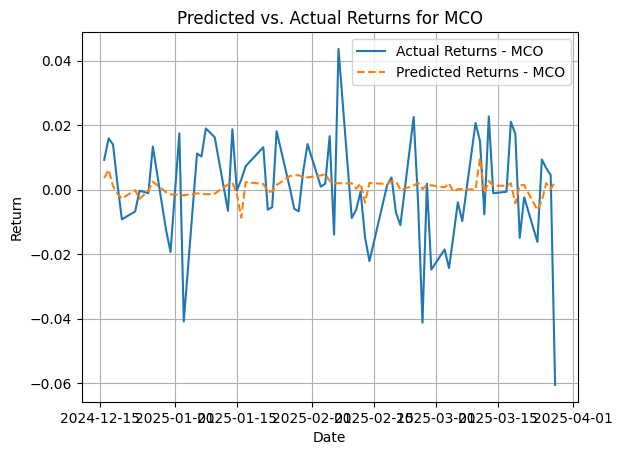

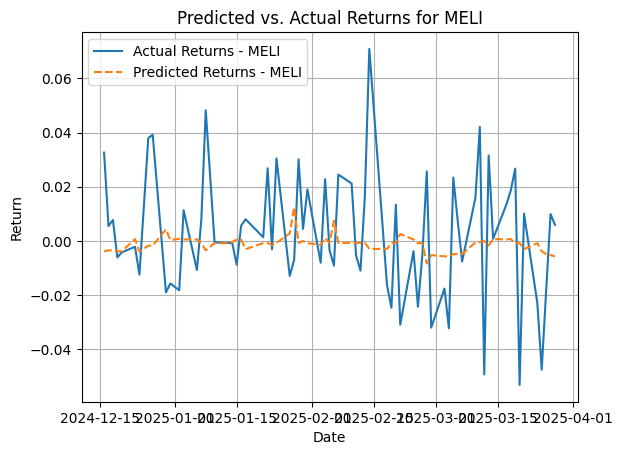

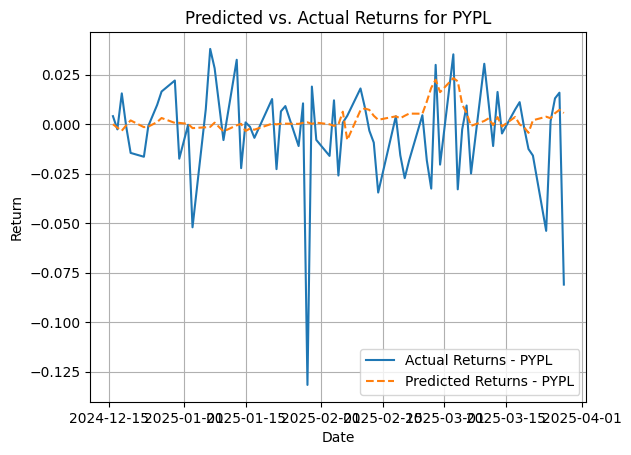

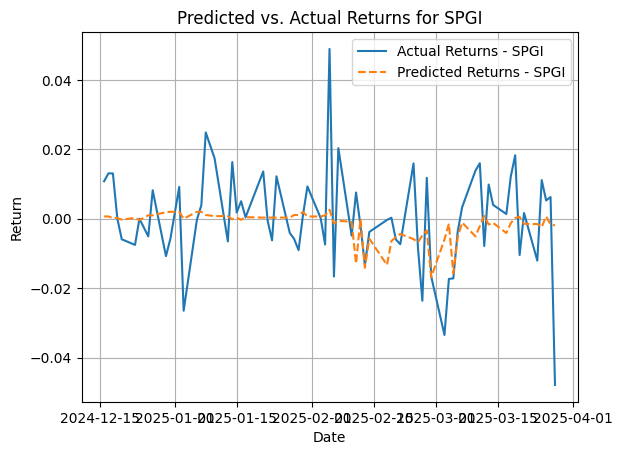

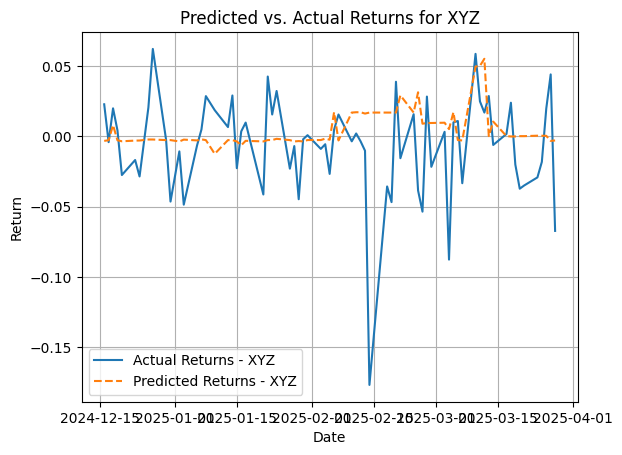

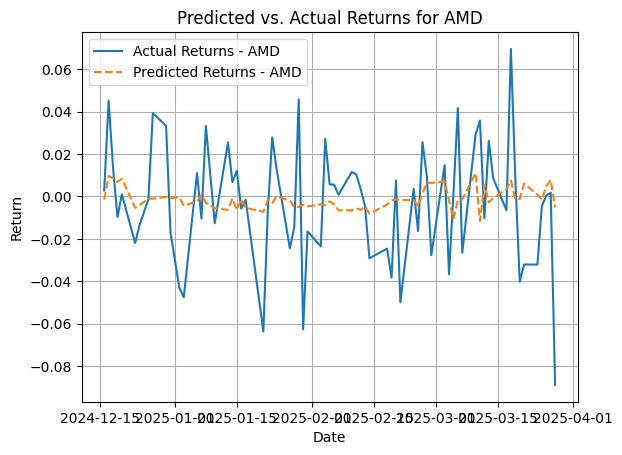

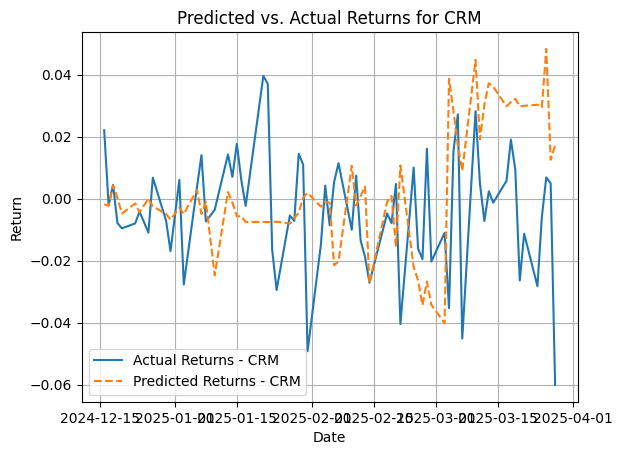

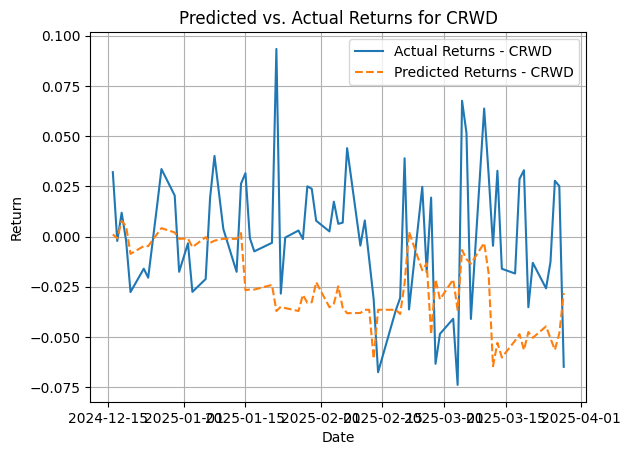

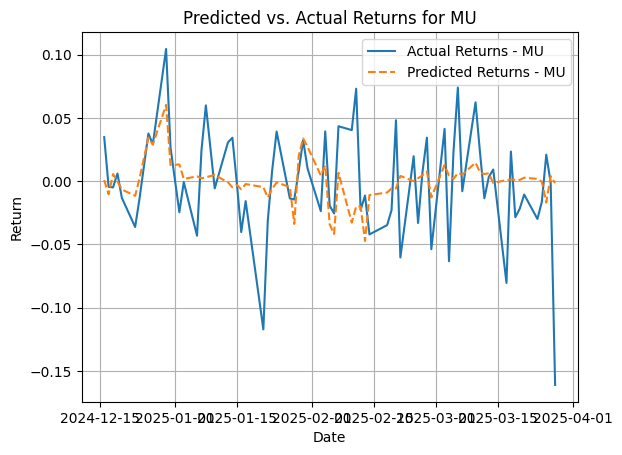

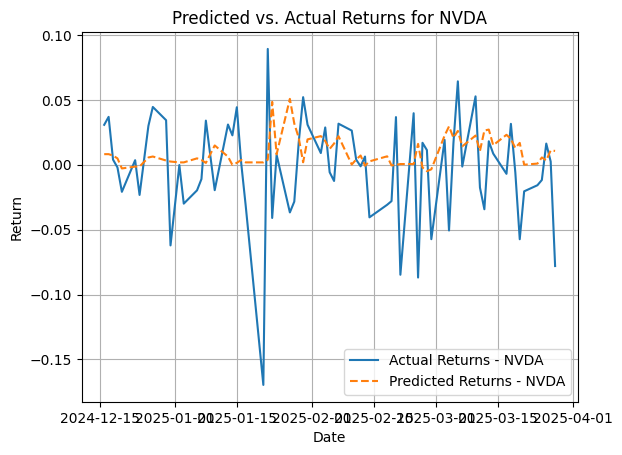

In [40]:
import matplotlib.pyplot as plt

# List of assets you want to plot
assets = ['BTC', 'ETH', 'XRP',
          'ABNB', 'AMZN', 'HD', 'LULU', 'TSLA',  # Consumer
                 'ISRG', 'LLY', 'MRNA', 'REGN', 'VRTX',  # Healthcare
                 'MCO', 'MELI', 'PYPL', 'SPGI', 'XYZ',   # Financials
                 'AMD', 'CRM', 'CRWD', 'MU', 'NVDA']  # Add all assets you're working with here

# Extract actual returns and predicted values for each asset
plt.figure(figsize=(12, 6))

for asset in assets:
    # Create target (Next 4 day's return)
    target = data[asset].pct_change().shift(-4).rename('target')

    # Combine selected features and target
    aligned_data = pd.concat([features[selected_features], target], axis=1).dropna()

    # Separate features (X) and target (y)
    X = aligned_data[selected_features]
    y = aligned_data['target']

    # Time-based masks
    dates = X.index
    train_mask = dates <= train_end
    test_mask = (dates >= test_start) & (dates <= test_end)
    test_dates = X[test_mask].index

    # Split data
    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    # Extract actual returns and predicted values for each asset
    actual_returns = y_test.loc[test_dates]  # Assuming returns are in `data`
    predicted_returns = predictions[f'{asset}_pred']

    # Align predicted_returns with test_dates and drop NaNs
    predicted_returns = predictions[f'{asset}_pred'].reindex(test_dates)
    valid_mask = predicted_returns.notna()

    # Apply mask to both
    test_dates_aligned = test_dates[valid_mask]
    actual_returns_aligned = actual_returns[valid_mask]
    predicted_returns_aligned = predicted_returns[valid_mask]

    # Plot actual vs. predicted
    plt.plot(test_dates_aligned, actual_returns_aligned, label=f"Actual Returns - {asset}", linestyle="-")
    plt.plot(test_dates_aligned, predicted_returns_aligned, label=f"Predicted Returns - {asset}", linestyle="--")


    # Customize the plot
    plt.title(f"Predicted vs. Actual Returns for {asset}")
    plt.xlabel("Date")
    plt.ylabel("Return")
    plt.legend()
    plt.grid(True)
    plt.show()


**Growth - Directional accuacy**

In [41]:
import numpy as np
import pandas as pd

# List of assets to analyze
assets = ['BTC', 'ETH', 'XRP',
          'ABNB', 'AMZN', 'HD', 'LULU', 'TSLA',  # Consumer
          'ISRG', 'LLY', 'MRNA', 'REGN', 'VRTX',  # Healthcare
          'MCO', 'MELI', 'PYPL', 'SPGI', 'XYZ',   # Financials
          'AMD', 'CRM', 'CRWD', 'MU', 'NVDA']  # Tech

# Initialize DataFrame to store results
accuracy_results = pd.DataFrame(columns=["Asset", "Directional_Accuracy"])

for asset in assets:
    if asset in data.columns and f"{asset}_pred" in predictions.columns:
        # Compute 5-day forward actual returns
        actual_returns = data[asset].pct_change().shift(-4)

        # Select test dates and drop NaNs
        actual_returns = actual_returns.loc[test_dates].dropna()
        predicted_returns = predictions[f"{asset}_pred"].loc[test_dates].dropna()

        # Align actual and predicted returns
        actual_returns = actual_returns.reindex(predicted_returns.index)

        # Compute directional accuracy (mean of correct signs)
        if len(actual_returns) > 0:
            directional_accuracy = np.mean(np.sign(actual_returns) == np.sign(predicted_returns))
        else:
            directional_accuracy = np.nan  # If no valid data, return NaN

        # Store results
        accuracy_results = pd.concat([accuracy_results,
                                      pd.DataFrame({"Asset": [asset],
                                                    "Directional_Accuracy": [directional_accuracy]})],
                                      ignore_index=True)

# Sort results from highest to lowest accuracy
accuracy_results = accuracy_results.sort_values(by="Directional_Accuracy", ascending=False).reset_index(drop=True)

# Display sorted results
print(accuracy_results)


   Asset  Directional_Accuracy
0   TSLA              0.685714
1     MU              0.600000
2    XRP              0.585714
3   REGN              0.585714
4   CRWD              0.585714
5   PYPL              0.571429
6    MCO              0.571429
7    LLY              0.557143
8   ISRG              0.557143
9    AMD              0.542857
10  LULU              0.542857
11   CRM              0.528571
12   BTC              0.514286
13  SPGI              0.514286
14   ETH              0.514286
15  AMZN              0.500000
16   XYZ              0.500000
17  NVDA              0.485714
18    HD              0.485714
19  ABNB              0.471429
20  VRTX              0.471429
21  MRNA              0.442857
22  MELI              0.428571


In [42]:
# Define thresholds
buy_threshold = 0.002     # Buy if predicted return > 0.2%
sell_threshold = -0.002   # Sell if predicted return < -0.2%

# Generate signals
test_mask = (predictions.index >= '2024-12-16') & (predictions.index <= test_end)
test_signals = pd.DataFrame(index=predictions[test_mask].index)

for asset in data.columns:
    test_signals[asset] = np.where(
        predictions.loc[test_mask, f'{asset}_pred'] > buy_threshold, 1,  # Buy
        np.where(
            predictions.loc[test_mask, f'{asset}_pred'] < sell_threshold, -1,  # Sell
            0  # Hold
        )
    )


**Growth - Splitting allocation between Growth stocks and Cryptocurrency**

In [43]:
# ======================
# 4. Risk Management (Fixed)
# ======================
def calculate_weights(data, signals):
    weights = pd.DataFrame(index=data.index, columns=data.columns)

    # Calculate volatility for each asset
    volatility = data.pct_change().rolling(10).std()

    # Different stop-loss rules
    for asset in data.columns:
        # Apply stop-loss
        rolling_high = data[asset].rolling(10).max()
        stop_loss_level = rolling_high * 0.85 if asset in ['BTC', 'ETH', 'XRP'] else rolling_high * 0.92
        signals[asset] = np.where(data[asset] < stop_loss_level, -1, signals[asset])

        # Inverse volatility weighting
        weights[asset] = 1 / volatility[asset]

    # Normalize weights and cap at 30%
    weights = weights.div(weights.sum(axis=1), axis=0)
    weights = weights.clip(0, 0.3)

    return weights

test_data = data.loc[test_start:test_end]
weights = calculate_weights(test_data, test_signals)

**Growth - Portfolio Backtesting**

In [44]:
# --- Setup ---
initial_capital = capital_input.value
remaining_cash = initial_capital
portfolio_history = []
weekly_trades_log = []
momentum_threshold = 0.003  # 0.3% momentum threshold

# Get top assets (from your accuracy results)
top_assets = accuracy_results['Asset'][:6].tolist()

# --- Preprocessing before main backtest loop ---

# Define backtest window based on allocation table
start_date = filtered_allocs['date'].min()
end_date = filtered_allocs['date'].max() + pd.Timedelta(days=6)

# Slice all input datasets to match the backtest window
filtered_test_data = test_data.loc[start_date:end_date]
filtered_test_signals = test_signals.loc[start_date:end_date]
predictions = predictions.loc[start_date:end_date]

# ✅ Filter weights by top_assets *first*, then slice date range
normalized_weights = weights[top_assets].loc[start_date:end_date]

# Normalize the weights (row-wise normalization to ensure sum of each row is 1)
normalized_weights = normalized_weights.div(normalized_weights.sum(axis=1), axis=0)

# --- Main Processing Function ---
def run_weekly_backtest(data_window, capital, weights, signals, predictions):
    """Run backtest for one week's data with momentum threshold"""
    positions = pd.DataFrame(index=data_window.index, columns=data_window.columns).fillna(0)
    entry_prices = pd.DataFrame(index=data_window.index, columns=data_window.columns).fillna(np.nan)
    portfolio_values = []
    trades = []

    for i, date in enumerate(data_window.index):
        daily_portfolio_value = capital  # Start with cash

        for asset in top_assets:
            price = data_window.loc[date, asset]
            signal = signals.loc[date, asset]
            weight = normalized_weights.loc[date, asset]
            current_position = positions.loc[date, asset]

            # --- Buy Logic with Momentum Threshold ---
            if signal == 1 and current_position == 0 and capital > 0:
                try:
                    # Calculate momentum difference
                    predicted_today = predictions.loc[date, f'{asset}_pred']
                    previous_date = predictions.index[predictions.index.get_loc(date) - 1]
                    predicted_yesterday = predictions.loc[previous_date, f'{asset}_pred']
                    predicted_diff = predicted_today - predicted_yesterday
                except Exception as e:
                    predicted_diff = 0

                # Only buy if momentum exceeds threshold
                if predicted_diff > momentum_threshold:
                    position_size = (capital * weight) / price
                    fee = position_size * price * 0.001
                    total_cost = position_size * price + fee

                    if total_cost <= capital:
                        positions.loc[date, asset] = position_size
                        entry_prices.loc[date, asset] = price
                        capital -= total_cost

                        trades.append({
                            'Date': date,
                            'Asset': asset,
                            'Action': 'Buy',
                            'Price': price,
                            'Size': position_size,
                            'Fee': fee,
                            'Capital_After_Trade': capital,
                            'Entry_Price': price,
                            'Momentum': predicted_diff
                        })

            # --- Sell Logic ---
            entry_price = entry_prices.loc[date, asset]
            if current_position > 0 and not pd.isna(entry_price):
                take_profit = 1.1 * entry_price
                stop_loss = 0.98 * entry_price

                if price >= take_profit or price <= stop_loss or signal == -1:
                    sell_value = current_position * price
                    fee = sell_value * 0.001
                    net_proceeds = sell_value - fee
                    capital += net_proceeds

                    trades.append({
                        'Date': date,
                        'Asset': asset,
                        'Action': 'Sell',
                        'Price': price,
                        'Size': current_position,
                        'Fee': fee,
                        'Capital_After_Trade': capital,
                        'Entry_Price': entry_price,
                        'P/L': (price - entry_price) * current_position - fee
                    })

                    positions.loc[date, asset] = 0
                    entry_prices.loc[date, asset] = np.nan

        # Carry positions forward to next day
        if i < len(data_window.index) - 1:
            next_date = data_window.index[i + 1]
            positions.loc[next_date] = positions.loc[date].copy()
            entry_prices.loc[next_date] = entry_prices.loc[date].copy()

        # Calculate daily portfolio value
        portfolio_value = capital + (positions.loc[date] * data_window.loc[date]).sum()
        portfolio_values.append(portfolio_value)

    portfolio_df = pd.DataFrame({'Portfolio_Value': portfolio_values}, index=data_window.index)
    trades_df = pd.DataFrame(trades)
    return portfolio_df, trades_df

# --- Loop through each week's allocation ---
for i, row in filtered_allocs.iterrows():
    week_start = row['date']
    growth_weight = row['Growth']

    # Compute capital for this week
    weekly_capital = remaining_cash * growth_weight
    print(f"\n{week_start.date()} | Growth Allocation: {growth_weight:.1%} → ${weekly_capital:,.2f}")

    # Get 1-week window of data
    week_end = week_start + pd.Timedelta(days=6)
    week_data = filtered_test_data.loc[week_start:week_end]
    week_signals = filtered_test_signals.loc[week_start:week_end]

    if week_data.empty:
        print(f"⚠️ No data for week {week_start.date()}")
        continue

    try:
        # Run backtest with momentum threshold
        portfolio_df, trades_df = run_weekly_backtest(
            data_window=week_data,
            capital=weekly_capital,
            weights=normalized_weights.loc[week_data.index],
            signals=week_signals,
            predictions=predictions.loc[week_data.index]
        )

        final_value = portfolio_df['Portfolio_Value'].iloc[-1]

        # Log trades with execution week
        trades_df["Trade_Week"] = week_start
        weekly_trades_log.append(trades_df)

        # Track performance
        portfolio_history.append({
            'Week_Start': week_start,
            'Capital_Allocated': weekly_capital,
            'Final_Value': final_value,
            'Net_Return': final_value - weekly_capital,
            'Return_Pct': (final_value / weekly_capital - 1) * 100
        })

        # Update remaining cash
        remaining_cash += final_value - weekly_capital

    except Exception as e:
        print(f"❌ Error during {week_start.date()}: {str(e)}")

# --- Combine Results ---
performance_df = pd.DataFrame(portfolio_history)
g_all_trades_df = pd.concat(weekly_trades_log, ignore_index=True)
growth_trades_log = [g_all_trades_df]  # 👈 Makes it available globally for daily tracking

# Calculate trade counts per week
trade_counts = (
    g_all_trades_df
    .groupby('Trade_Week')
    .agg({
        'Asset': 'count',
        'Momentum': 'mean'
    })
    .rename(columns={
        'Asset': 'Trades_Executed',
        'Momentum': 'Avg_Momentum'
    })
    .reset_index()
)

# Merge with performance data
performance_df = performance_df.merge(
    trade_counts,
    left_on='Week_Start',
    right_on='Trade_Week',
    how='left'
).fillna({'Trades_Executed': 0, 'Avg_Momentum': 0})

growth_results = performance_df.rename(columns={"Week_Start": "date"})

# --- Display Results ---
print(f"\n{' Final Results ':=^50}")
print(f"Total Return: {(remaining_cash/initial_capital-1)*100:.1f}%")

display(performance_df.style.format({
    'Week_Start': '{:%Y-%m-%d}',
    'Capital_Allocated': '${:,.2f}',
    'Final_Value': '${:,.2f}',
    'Net_Return': '${:,.2f}',
    'Return_Pct': '{:.1f}%',
    'Trades_Executed': '{:.0f}',
    'Avg_Momentum': '{:.4f}'
}))


2025-02-24 | Growth Allocation: 30.0% → $3,000.00

2025-03-03 | Growth Allocation: 30.0% → $2,992.66

2025-03-10 | Growth Allocation: 20.0% → $1,991.08

2025-03-17 | Growth Allocation: 20.0% → $1,994.40

2025-03-24 | Growth Allocation: 20.0% → $1,992.80

================= Final Results ==================
Total Return: -0.5%


,Week_Start,Capital_Allocated,Final_Value,Net_Return,Return_Pct,Trade_Week,Trades_Executed,Avg_Momentum
0,2025-02-24,"$3,000.00","$2,975.54",$-24.46,-0.8%,2025-02-24 00:00:00,2,0.0061
1,2025-03-03,"$2,992.66","$2,972.54",$-20.13,-0.7%,2025-03-03 00:00:00,2,0.0053
2,2025-03-10,"$1,991.08","$2,007.65",$16.57,0.8%,2025-03-10 00:00:00,3,0.0038
3,2025-03-17,"$1,994.40","$1,986.39",$-8.01,-0.4%,2025-03-17 00:00:00,2,0.0212
4,2025-03-24,"$1,992.80","$1,977.05",$-15.75,-0.8%,2025-03-24 00:00:00,4,0.0086


**Growth - Daily value**

,Date,Week,Condition,Total_Growth_Crypto_Value
5,2025-03-01,2025-02-24,neutral,2976.38
6,2025-03-02,2025-02-24,neutral,2976.38
7,2025-03-03,2025-03-03,neutral,2992.66
8,2025-03-04,2025-03-03,neutral,2992.66
9,2025-03-05,2025-03-03,neutral,2992.66
10,2025-03-06,2025-03-03,neutral,2992.66
11,2025-03-07,2025-03-03,neutral,2972.77
12,2025-03-08,2025-03-03,neutral,2972.77
13,2025-03-09,2025-03-03,neutral,2972.77
14,2025-03-10,2025-03-10,bearish,1991.08


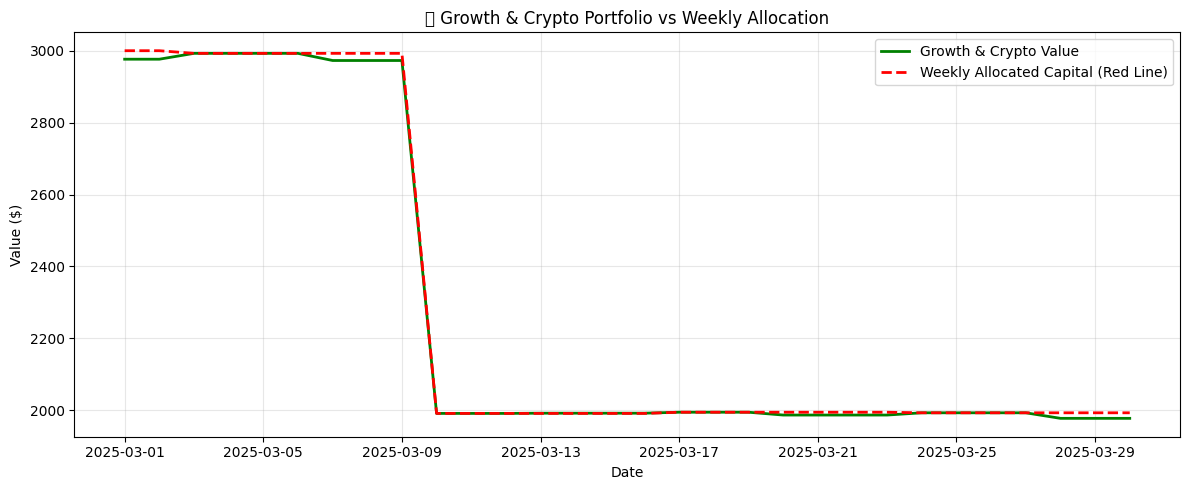

In [45]:
# ✅ Daily Value Tracker for Growth/Crypto (using weekly_trades_log)

if 'weekly_trades_log' in globals() and weekly_trades_log:
    all_growth_trades_df = pd.concat(weekly_trades_log, ignore_index=True)
else:
    raise ValueError("weekly_trades_log not found or is empty. Run your growth backtest first.")

# Setup
growth_day_to_day = []

# Initialize
start_date = pd.to_datetime(start_date_input.value)
end_date = pd.to_datetime(end_date_input.value)
current_total_value = capital_input.value

# Lookup table from growth_results
rebalance_lookup_growth = growth_results.set_index("date")["Capital_Allocated"].to_dict()

# Start loop through allocation table
for i, row in filtered_allocs.iterrows():
    week_start = pd.to_datetime(row['date'])
    if week_start > end_date:
        break

    condition = row['condition']
    vix = row['vix']
    allocation = decide_allocation(condition, vix=vix)
    growth_pct = allocation.get('Growth', 0)

    # Allocation fallback
    allocated_to_growth = rebalance_lookup_growth.get(week_start, current_total_value * growth_pct)
    day_revenue_growth = allocated_to_growth

    # Generate 7-day window
    week_dates = pd.date_range(start=week_start, periods=7, freq='D')
    for date in week_dates:
        if date > end_date:
            break

        # Add realized gains from trades that SELL on this date
        closed_trades = all_growth_trades_df[
            (all_growth_trades_df['Action'].str.lower() == "sell") &
            (pd.to_datetime(all_growth_trades_df['Date']) == date)
        ]


        if not closed_trades.empty:
            net_gain_today = closed_trades['P/L'].sum()
            day_revenue_growth += net_gain_today

        growth_day_to_day.append({
            "Date": date,
            "Week": week_start,
            "Condition": condition,
            "Total_Growth_Crypto_Value": round(day_revenue_growth, 2)
        })

    current_total_value = day_revenue_growth

# Final DataFrame
growth_day_to_day_df = pd.DataFrame(growth_day_to_day)

# Final DataFrame
growth_day_to_day_df = pd.DataFrame(growth_day_to_day)

# 🔥 Filter out early dates based on user-defined start_date
growth_day_to_day_df = growth_day_to_day_df[growth_day_to_day_df['Date'] >= start_date]

display(growth_day_to_day_df)

# Plot
plt.figure(figsize=(12, 5))

# Plot actual daily value of Growth & Crypto portfolio
plt.plot(
    growth_day_to_day_df['Date'],
    growth_day_to_day_df['Total_Growth_Crypto_Value'],
    label='Growth & Crypto Value',
    color='green',
    linewidth=2
)

# 🧠 Build allocation overlay from growth_results
growth_allocation_line = []
rebalance_lookup_growth = growth_results.set_index("date")["Capital_Allocated"].to_dict()

for week_start, allocation in rebalance_lookup_growth.items():
    week_dates = pd.date_range(start=week_start, periods=7, freq='D')
    for date in week_dates:
        if date > end_date:
            break
        growth_allocation_line.append({'Date': date, 'Weekly_Allocation_Value': allocation})

# Convert to DataFrame
growth_alloc_df = pd.DataFrame(growth_allocation_line)

# Merge to align with daily value dataframe
combined_growth_plot = pd.merge(
    growth_day_to_day_df,
    growth_alloc_df,
    on='Date',
    how='left'
).ffill()

# 🟥 Plot red allocation line
plt.plot(
    combined_growth_plot['Date'],
    combined_growth_plot['Weekly_Allocation_Value'],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Weekly Allocated Capital (Red Line)'
)

# Final chart settings
plt.title('🚀 Growth & Crypto Portfolio vs Weekly Allocation')
plt.xlabel('Date')
plt.ylabel('Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



**Growth - Performance Metrics**

In [46]:
import numpy as np
import pandas as pd

def compute_performance_metrics(portfolio_df, trade_log, risk_free_rate=0.0):
    """
    Compute key performance metrics.

    Parameters:
        portfolio_df (DataFrame): DataFrame with datetime index and a column 'Portfolio_Value'
                                  representing the portfolio value over time.
        trade_log (DataFrame): DataFrame with columns:
                              'Asset', 'Entry_Date', 'Exit_Date', 'Entry_Price', 'Exit_Price', 'Profit'
        risk_free_rate (float): Annual risk-free rate (default = 0)

    Returns:
        metrics (dict): A dictionary of performance metrics.
    """
    # Ensure the index is datetime
    portfolio_df.index = pd.to_datetime(portfolio_df.index)

    # --- Annual Return ---
    initial_value = portfolio_df['Portfolio_Value'].iloc[0]
    final_value = portfolio_df['Portfolio_Value'].iloc[-1]
    total_days = (portfolio_df.index[-1] - portfolio_df.index[0]).days
    annual_return = (final_value / initial_value) ** (252 / total_days) - 1 if total_days > 0 else np.nan

    # --- Annual Volatility ---
    portfolio_df['Daily_Return'] = portfolio_df['Portfolio_Value'].pct_change()
    daily_volatility = portfolio_df['Daily_Return'].std()
    annual_volatility = daily_volatility * np.sqrt(252)

    # --- Sharpe Ratio ---
    sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility if annual_volatility != 0 else np.nan

    # --- Max Drawdown ---
    cum_max = portfolio_df['Portfolio_Value'].cummax()
    drawdown = (portfolio_df['Portfolio_Value'] - cum_max) / cum_max
    max_drawdown = drawdown.min()  # Typically a negative number

    # --- Drawdown Events ---
    drawdown_events = 0
    peak = portfolio_df['Portfolio_Value'].iloc[0]
    for value in portfolio_df['Portfolio_Value']:
        if value > peak:
            peak = value
        elif (peak - value) / peak > 0:
            drawdown_events += 1

    # --- Trade Log Metrics ---
    num_trades = len(trade_log)

    if num_trades > 0:
        win_rate = (trade_log['Profit'] > 0).sum() / num_trades
        # Calculate holding period in days for each trade
        trade_log['Holding_Period'] = (pd.to_datetime(trade_log['Exit_Date']) - pd.to_datetime(trade_log['Entry_Date'])).dt.days
        avg_holding_period = trade_log['Holding_Period'].mean()
        profit_per_trade = trade_log['Profit'].mean()
    else:
        win_rate = np.nan
        avg_holding_period = np.nan
        profit_per_trade = np.nan

    metrics = {
        'Annual Return (%)': annual_return * 100,
        'Annual Volatility (%)': annual_volatility * 100,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown (%)': max_drawdown * 100,
        'Drawdown Events': drawdown_events,
        'Number of Trades': num_trades,
        'Win Rate (%)': win_rate * 100 if not np.isnan(win_rate) else np.nan,
        'Average Holding Period (days)': avg_holding_period,
        'Profit per Trade': profit_per_trade
    }

    return metrics



In [47]:
trade_log_df = pd.concat(weekly_trades_log, ignore_index=True)

# Calculate profit: Profit = (Sell Price - Entry Price) * Size
trade_log_df['Profit'] = 0.0  # Initialize the Profit column

for i in range(len(trade_log_df)):
    if trade_log_df.loc[i, 'Action'] == 'Sell':
        entry_price = trade_log_df.loc[i, 'Entry_Price']
        sell_price = trade_log_df.loc[i, 'Price']
        size = trade_log_df.loc[i, 'Size']

        # Profit before transaction costs
        raw_profit = (sell_price - entry_price) * size

        # Subtract transaction fees (assuming buy and sell fees were already recorded)
        trade_log_df.loc[i, 'Profit'] = raw_profit


# Add Exit_Date column by shifting Entry_Date for Sell actions
trade_log_df['Exit_Date'] = None  # Initialize the column

# Track open positions
open_positions = {}

for i in range(len(trade_log_df)):
    asset = trade_log_df.loc[i, 'Asset']
    action = trade_log_df.loc[i, 'Action']
    date = trade_log_df.loc[i, 'Date']

    if action == 'Buy':
        open_positions[asset] = date  # Store entry date
    elif action == 'Sell' and asset in open_positions:
        trade_log_df.loc[i, 'Exit_Date'] = date  # Assign exit date
        trade_log_df.loc[i, 'Entry_Date'] = open_positions[asset]  # Set corresponding buy date
        del open_positions[asset]  # Remove from open positions

# Ensure it's a datetime column
trade_log_df['Entry_Date'] = pd.to_datetime(trade_log_df['Entry_Date'])
trade_log_df['Exit_Date'] = pd.to_datetime(trade_log_df['Exit_Date'])

# Now call the function with the fixed trade log
metrics = compute_performance_metrics(portfolio_df, trade_log_df)

# Convert to DataFrame and round numeric values
metrics_df = pd.DataFrame(metrics.items(), columns=["Metric", "Value"])
metrics_df["Value"] = metrics_df["Value"].apply(lambda x: round(x, 2) if isinstance(x, float) else x)

# Display the formatted DataFrame
print(metrics_df.to_string(index=False))

                       Metric  Value
            Annual Return (%) -39.34
        Annual Volatility (%)   6.44
                 Sharpe Ratio  -6.11
             Max Drawdown (%)  -0.81
              Drawdown Events   2.00
             Number of Trades  13.00
                 Win Rate (%)   7.69
Average Holding Period (days)   1.17
             Profit per Trade  -4.96


# Gold & Cash

**Gold & Cash - Initial allocation**

In [48]:
# Use first week of filtered allocation
first_week = filtered_allocs.iloc[0]

# Extract condition and VIX
condition = first_week["condition"]
vix = first_week["vix"]

# Run allocation logic
allocation = decide_allocation(condition, vix=vix)

# Get gold and cash %
gold_pct = allocation.get('Gold', 0)
cash_pct = allocation.get('Cash',0)
gold_cash_pct = gold_pct + cash_pct


# Compute Gold Capital
gold_cash_capital = capital_input.value *(gold_cash_pct)
print(f"{first_week['date']} | Condition: {condition.upper()} | VIX: {vix}")
print(f"Gold and Cash Allocation: {gold_cash_pct*100:.2f}% → ${gold_cash_capital:.2f}")

2025-02-24 00:00:00 | Condition: NEUTRAL | VIX: 19.6299991607666
Gold and Cash Allocation: 35.00% → $3500.00


**Gold & Cash - retrieving data**

In [49]:
# ======================
# STEP 1: Fetch Gold (XAU/USD) and USD (DXY) Data
# ======================
def fetch_data():
    end_date = datetime.datetime.now().strftime('%Y-%m-%d')
    data = yf.download(tickers=["GC=F", "DX-Y.NYB"],
                      start="2020-03-23",
                      end=end_date,
                      group_by='ticker')

    # Stack the multi-index columns
    gold = data["GC=F"].copy()
    gold['Asset'] = 'Gold'

    usd = data["DX-Y.NYB"].copy()
    usd['Asset'] = 'USD'

    # Combine vertically
    df = pd.concat([gold, usd])

    # Reset index to make Date a column
    df = df.reset_index()

    return df

df = fetch_data()

[*********************100%***********************]  2 of 2 completed


**Gold & Cash - Feature engineering**

In [50]:
# ======================
# STEP 2: Feature Engineering
# ======================
def add_features(df):
    # Sort by Asset and Date
    df = df.sort_values(by=['Asset', 'Date'])

    # Calculate features for each asset
    def _add_asset_features(group):
        group = group.copy()
        group['Return'] = group['Close'].pct_change()
        group['MA5'] = group['Close'].rolling(window=5).mean()
        group['MA10'] = group['Close'].rolling(window=10).mean()
        group['MA20'] = group['Close'].rolling(window=20).mean()
        group['Volatility'] = group['Close'].rolling(window=10).std()

        # 5-day forward target
        group['Future_Close'] = group['Close'].shift(-5)
        group['Future_Return'] = (group['Future_Close'] - group['Close']) / group['Close']
        group['Target'] = (group['Future_Return'] > 0).astype(int)
        return group

    # Apply to each asset group
    df = df.groupby('Asset').apply(_add_asset_features).reset_index(drop=True)
    return df

df = add_features(df)

**Gold & Cash - Adding technical indicators**

In [51]:
# ======================
# STEP 3: Technical Indicators (RSI, MACD, Bollinger Bands)
# ======================
def add_technical_indicators(df):
    df = df.copy()

    # RSI (14-period)
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # MACD (12-26-9)
    ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_12 - ema_26
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

    # Bollinger Bands (20-day MA ± 2 std dev)
    ma20 = df['Close'].rolling(window=20).mean()
    std20 = df['Close'].rolling(window=20).std()
    df['BB_upper'] = ma20 + 2 * std20
    df['BB_lower'] = ma20 - 2 * std20

    return df

df = add_technical_indicators(df)

# Drop NaN values
required_cols = ['Return', 'MA5', 'MA10', 'MA20', 'Volatility', 'RSI', 'MACD', 'MACD_Signal', 'BB_upper', 'BB_lower', 'Target']
df = df.dropna(subset=required_cols)

**Gold & Cash - Model training**

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.73      0.68       271
           1       0.68      0.58      0.62       263

    accuracy                           0.66       534
   macro avg       0.66      0.65      0.65       534
weighted avg       0.66      0.66      0.65       534

Confusion Matrix:
 [[198  73]
 [111 152]]


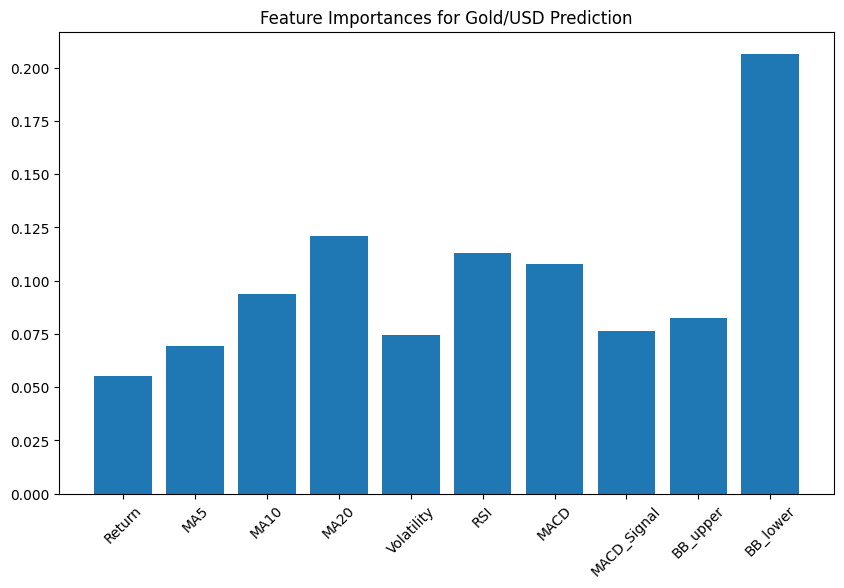

In [52]:
# ======================
# STEP 4: Train Machine Learning Model
# ======================
features = ['Return', 'MA5', 'MA10', 'MA20', 'Volatility', 'RSI', 'MACD', 'MACD_Signal', 'BB_upper', 'BB_lower']

# Balance the dataset
df_majority = df[df['Target'] == 1]
df_minority = df[df['Target'] == 0]
df_minority_upsampled = df_minority.sample(n=len(df_majority), replace=True, random_state=42)
df_balanced = pd.concat([df_majority, df_minority_upsampled]).sample(frac=1, random_state=42)

X = df_balanced[features]
y = df_balanced['Target']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train Gradient Boosting model
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Evaluate model
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Feature Importance
plt.figure(figsize=(10, 6))
plt.bar(features, model.feature_importances_)
plt.title("Feature Importances for Gold/USD Prediction")
plt.xticks(rotation=45)
plt.show()

Gold & Cash - Backtesting

In [53]:
def diversified_backtest_confidence_weighted_realistic_limited_units(
    df,
    model,
    initial_capital,
    confidence_threshold,
    take_profit,
    stop_loss,
    holding_period,
    max_positions,
    start_date,
    end_date
):
    """
    Realistic backtest with unit-based (whole shares) logic,
    per-stock forward navigation, confidence-weighted capital allocation,
    capped take profit / stop loss, and limited concurrent positions.
    Includes a 0.1% transaction fee for buying and selling.
    """
    df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()
    df['prediction'] = model.predict(df[features])
    df['proba'] = model.predict_proba(df[features])[:, 1]
    df = df.sort_values(by='Date').reset_index(drop=True)

    cash = initial_capital
    active_trades = {}
    trade_log = []
    portfolio_history = []

    dates = df['Date'].unique()

    for current_date in dates:
        today_rows = df[df['Date'] == current_date]

        # === Release expired trades ===
        expired = [s for s, (sell_date, _, _, _) in active_trades.items() if sell_date <= current_date]
        for stock in expired:
            _, _, _, capital_allocated = active_trades[stock]
            cash += capital_allocated
            del active_trades[stock]

        # === Execute new trades ===
        for _, row in today_rows.iterrows():
            stock = row['Asset']
            proba = row['proba']

            if stock in active_trades:
                continue

            if len(active_trades) >= max_positions:
                break

            if row['prediction'] == 1 and proba >= confidence_threshold:
                confidence_score = (proba - confidence_threshold) / (1 - confidence_threshold)
                capital_to_allocate = cash * confidence_score

                buy_price = row['Close']
                shares = capital_to_allocate / buy_price
                if shares == 0:
                    continue

                total_cost = shares * buy_price
                transaction_fee = total_cost * 0.001  # 0.1% buy fee
                total_cost += transaction_fee

                # Forward lookup in same stock
                stock_df = df[df['Asset'] == stock].sort_values(by='Date')
                future_rows = stock_df[stock_df['Date'] > current_date]

                if len(future_rows) < holding_period:
                    continue

                sell_row = future_rows.iloc[holding_period - 1]
                sell_price = sell_row['Close']
                sell_date = sell_row['Date']

                revenue = shares * sell_price
                raw_profit = revenue - total_cost
                pct_return = (sell_price - buy_price) / buy_price
                pct_return = min(max(pct_return, stop_loss), take_profit)

                capped_sell_price = buy_price * (1 + pct_return)
                capped_revenue = shares * capped_sell_price
                sell_fee = capped_revenue * 0.001  # 0.1% sell fee
                actual_profit = capped_revenue - total_cost - sell_fee

                active_trades[stock] = (sell_date, buy_price, shares, capped_revenue - sell_fee)
                cash -= total_cost

                trade_log.append({
                    'Date': current_date,
                    'Sell Date': sell_date,
                    'Asset': stock,
                    'Buy Price': round(buy_price, 2),
                    'Sell Price': round(sell_price, 2),
                    'Confidence': round(proba, 4),
                    'Units': shares,
                    'Capital Allocated': round(total_cost, 2),
                    'Profit (%)': round(pct_return * 100, 2),
                    'Profit ($)': round(actual_profit, 2)
                })

        # === Portfolio valuation ===
        active_value = sum(alloc for _, _, _, alloc in active_trades.values())
        total_portfolio = cash + active_value
        portfolio_history.append({
            'Date': current_date,
            'Portfolio_Value': total_portfolio
        })

    portfolio_df = pd.DataFrame(portfolio_history)
    trades_df = pd.DataFrame(trade_log)

    return portfolio_df, trades_df

**Gold & Cash - Confidence levels**

In [54]:
# Setup
confidence_levels = [0.50, 0.525, 0.55, 0.575, 0.60, 0.625, 0.65, 0.70, 0.75, 0.80, 0.90, 1.00]
initial_cash = gold_cash_capital

# Capital allocation thresholds
min_pct = 0.08   # 8% at 0.50
mid_pct = 0.15   # 15% at 0.60
max_pct = 0.30   # 30% at 1.00

# Desired minimal increase from 0.60 to 0.625
linear_step = (mid_pct - min_pct) / (0.60 - 0.50)  # = 0.07 / 0.10 = 0.7 per confidence
min_exp_jump = linear_step * 0.025  # 0.0175 (smallest step upward in exponential)

# Back-calculate the exponent needed
# We want: mid_pct + ((0.625 - 0.60)/0.4)^power * (max_pct - mid_pct) ≈ 0.15 + min_exp_jump
target_pct_at_625 = mid_pct + min_exp_jump  # ≈ 0.1675
target_score = (target_pct_at_625 - mid_pct) / (max_pct - mid_pct)
exp_input = (0.625 - 0.60) / (1.00 - 0.60)  # = 0.025 / 0.4 = 0.0625

# Solve for power: exp_input^power = target_score
import math
exp_power = math.log(target_score) / math.log(exp_input)

# Final power for exponential curve
exp_power = round(exp_power, 3)  # you can print this if curious

# Table calculation
data = []
for c in confidence_levels:
    if c < 0.50:
        capital_pct = 0.0
    elif c <= 0.60:
        score = (c - 0.50) / (0.60 - 0.50)
        capital_pct = min_pct + score * (mid_pct - min_pct)
    else:
        score = ((c - 0.60) / (1.00 - 0.60)) ** exp_power
        capital_pct = mid_pct + score * (max_pct - mid_pct)

    capital_pct = max(0, min(1, capital_pct))
    capital_invested = round(initial_cash * capital_pct, 2)
    percent_allocated = round(capital_pct * 100, 1)

    data.append({
        'Confidence': c,
        'Capital Invested ($)': capital_invested,
        '% of Capital': f"{percent_allocated}%",
        'Exponent': exp_power if c > 0.60 else 'Linear'
    })

investment_table = pd.DataFrame(data)
print("📊 Confidence-to-Capital Allocation Table (Smoothed Exponential Scaling):")
print(investment_table)


📊 Confidence-to-Capital Allocation Table (Smoothed Exponential Scaling):
    Confidence  Capital Invested ($) % of Capital Exponent
0        0.500                280.00         8.0%   Linear
1        0.525                341.25         9.8%   Linear
2        0.550                402.50        11.5%   Linear
3        0.575                463.75        13.2%   Linear
4        0.600                525.00        15.0%   Linear
5        0.625                586.23        16.7%    0.775
6        0.650                629.78        18.0%    0.775
7        0.700                704.29        20.1%    0.775
8        0.750                770.49        22.0%    0.775
9        0.800                831.80        23.8%    0.775
10       0.900                945.08        27.0%    0.775
11       1.000               1050.00        30.0%    0.775


**Gold & Cash - Running model**

In [55]:
initial_capital = capital_input.value
remaining_cash = initial_capital
gold_cash_history = []
weekly_trades_log = []

for i,row in filtered_allocs.iterrows():
    week_start = row['date']
    condition = row['condition']
    vix = row['vix']

    allocation = decide_allocation(condition, vix=vix)
    gold_pct = allocation.get('Gold', 0)
    cash_pct = allocation.get('Cash',0)
    gold_cash_pct = gold_pct + cash_pct

    gold_cash_capital = remaining_cash * gold_cash_pct
    print(f"{week_start} | {condition.upper()} | VIX: {vix:.2f} → ${gold_cash_capital:.2f} to Gold Cash")

    try:
        portfolio_df, trades_df = diversified_backtest_confidence_weighted_realistic_limited_units(
        df,
        model,
        initial_capital=remaining_cash*gold_cash_pct,
        confidence_threshold=0.5,
        take_profit=0.1,
        stop_loss=-0.05,
        holding_period=5,
        max_positions=7,
        start_date = week_start,
        end_date = week_start + pd.Timedelta(weeks=6))
        final_value = portfolio_df['Portfolio_Value'].iloc[-1]
        trades_df["Trade_Week"] = pd.to_datetime(trades_df["Date"]).dt.to_period("W").dt.start_time
        weekly_trades_log.append(trades_df)

        gold_cash_history.append({
            'date': week_start,
            'capital_allocated': gold_cash_capital,
            'final_value': final_value,
            'net_gain': final_value - gold_cash_capital,
            'trades': len(trades_df)
        })
        remaining_cash += final_value - gold_cash_capital

    except Exception as e:
        print(f"❌ Error during trading on {week_start}: {e}")


# --- Combine all trades ---
c_all_trades_df = pd.concat(weekly_trades_log, ignore_index=True)

# Filter out trades after user's end date
end_date = pd.to_datetime(end_date_input.value)
c_all_trades_df = c_all_trades_df[pd.to_datetime(c_all_trades_df["Date"]) <= end_date]

# Calculate number of executed trades per actual Trade_Week
trade_counts = (
    c_all_trades_df
    .groupby("Trade_Week")
    .size()
    .reset_index(name="Number of Trades")
)

gold_cash_results = pd.DataFrame(gold_cash_history)
gold_cash_results = gold_cash_results.drop(columns=["trades"], errors="ignore")
gold_cash_results = gold_cash_results.merge(
    trade_counts,
    left_on="date",
    right_on="Trade_Week",
    how="left"
).drop(columns=["Trade_Week"])

gold_cash_results["Number of Trades"] = gold_cash_results["Number of Trades"].fillna(0).astype(int)

display(gold_cash_results)

2025-02-24 00:00:00 | NEUTRAL | VIX: 19.63 → $3500.00 to Gold Cash
2025-03-03 00:00:00 | NEUTRAL | VIX: 23.37 → $3537.93 to Gold Cash
2025-03-10 00:00:00 | BEARISH | VIX: 21.77 → $4611.32 to Gold Cash
2025-03-17 00:00:00 | BEARISH | VIX: 19.28 → $4694.79 to Gold Cash
2025-03-24 00:00:00 | BEARISH | VIX: 21.65 → $4737.69 to Gold Cash


,date,capital_allocated,final_value,net_gain,Number of Trades
0,2025-02-24,3500.000000,3608.377615,108.377615,1
1,2025-03-03,3537.932165,3676.925195,138.993030,2
2,2025-03-10,4611.316790,4796.807676,185.490886,3
3,2025-03-17,4694.787689,4790.135697,95.348008,8
4,2025-03-24,4737.694293,4826.885098,89.190806,5


**Gold & Cash - Daily values**

,Date,Week,Condition,Total_Gold_Cash_Value
5,2025-03-01,2025-02-24,neutral,3500.00
6,2025-03-02,2025-02-24,neutral,3500.00
7,2025-03-03,2025-03-03,neutral,3509.91
8,2025-03-04,2025-03-03,neutral,3509.91
9,2025-03-05,2025-03-03,neutral,3509.91
10,2025-03-06,2025-03-03,neutral,3509.91
11,2025-03-07,2025-03-03,neutral,3509.91
12,2025-03-08,2025-03-03,neutral,3509.91
13,2025-03-09,2025-03-03,neutral,3509.91
14,2025-03-10,2025-03-10,bearish,4605.00


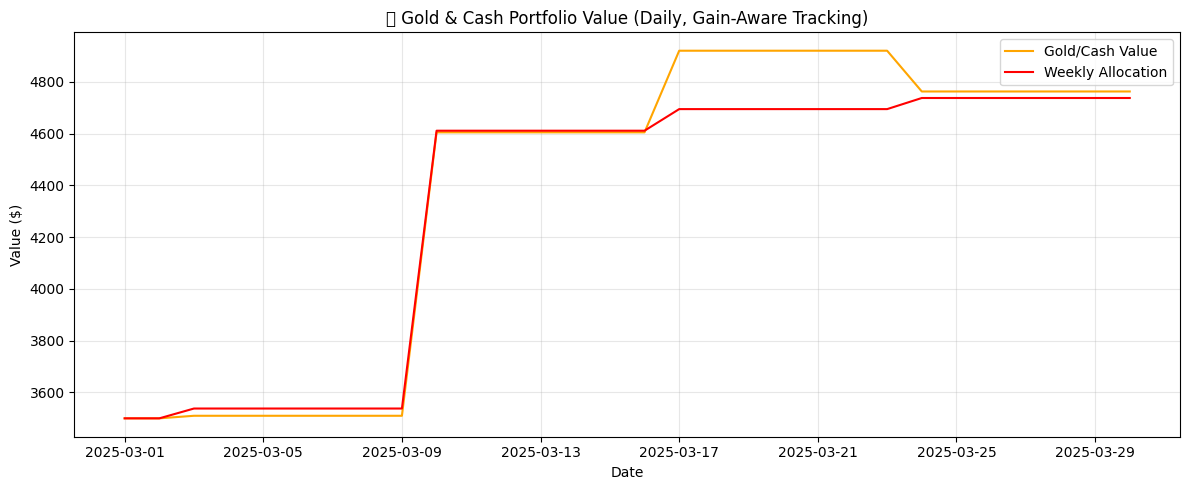

In [56]:
# ============================================
# GOLD/CASH DAILY VALUE TRACKING (UPDATED)
# ============================================

if 'weekly_trades_log' in globals():
    all_gold_cash_trades_df = pd.concat(weekly_trades_log, ignore_index=True)
else:
    raise ValueError("weekly_trades_log not found. Run your gold/cash backtest first.")

gold_cash_day_to_day = []

# Start and end dates
start_date = pd.to_datetime(start_date_input.value)
end_date = pd.to_datetime(end_date_input.value)

# Initialize with initial capital
current_total_portfolio_value = capital_input.value

# Build lookup for rebalancing targets
rebalance_lookup_div = gold_cash_results.set_index("date")["capital_allocated"].to_dict()

# Ensure Sell Date is datetime
all_gold_cash_trades_df['Sell Date'] = pd.to_datetime(all_gold_cash_trades_df['Sell Date'])

# Track ongoing value
day_revenue_div = 0

# Iterate through each week in filtered_allocs
for i, row in filtered_allocs.iterrows():
    week_start = pd.to_datetime(row['date'])
    if week_start > end_date:
        break

    condition = row['condition']
    vix = row['vix']

    # Determine allocation % for diversified (gold + cash)
    allocation = decide_allocation(condition, vix=vix)
    gold_pct = allocation.get('Gold', 0)
    cash_pct = allocation.get('Cash', 0)
    diversified_pct = gold_pct + cash_pct

    # Get the rebalanced allocation from gold_cash_results (fallback to computed)
    allocated_to_diversified = rebalance_lookup_div.get(week_start, current_total_portfolio_value * diversified_pct)

    # Adjust capital
    day_revenue_div = allocated_to_diversified

    # Generate daily values for this week
    week_dates = pd.date_range(start=week_start, periods=7, freq='D')
    for date in week_dates:
        if date > end_date:
            break

        # Track trades that closed today
        closed_trades_today = all_gold_cash_trades_df[
            all_gold_cash_trades_df['Sell Date'] == date
        ]
        if not closed_trades_today.empty:
            net_gain_today = closed_trades_today['Profit ($)'].sum()
            day_revenue_div += net_gain_today

        gold_cash_day_to_day.append({
            'Date': date,
            'Week': week_start,
            'Condition': condition,
            'Total_Gold_Cash_Value': round(day_revenue_div, 2)
        })

    # Update capital for next week
    current_total_portfolio_value = day_revenue_div

# Convert to DataFrame
gold_cash_day_to_day_df = pd.DataFrame(gold_cash_day_to_day)

gold_cash_day_to_day_df = gold_cash_day_to_day_df[gold_cash_day_to_day_df['Date'] >= start_date]

display(gold_cash_day_to_day_df)

# ============================================
# PLOT: Gold/Cash Value + Weekly Allocation Line
# ============================================

# Build allocation tracker
allocation_line = []
for i, row in gold_cash_day_to_day_df.iterrows():
    week = row['Week']
    alloc = rebalance_lookup_div.get(week, None)
    allocation_line.append(alloc if alloc is not None else np.nan)

gold_cash_day_to_day_df['Weekly_Allocation'] = allocation_line

# Plot
plt.figure(figsize=(12, 5))
plt.plot(gold_cash_day_to_day_df['Date'], gold_cash_day_to_day_df['Total_Gold_Cash_Value'], label='Gold/Cash Value', color='orange')
plt.plot(gold_cash_day_to_day_df['Date'], gold_cash_day_to_day_df['Weekly_Allocation'], color='red', linestyle='-', label='Weekly Allocation')

plt.title('🏦 Gold & Cash Portfolio Value (Daily, Gain-Aware Tracking)')
plt.xlabel('Date')
plt.ylabel('Value ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()


**Evaluation**

In [57]:
def compute_performance_metrics_dynamic(portfolio_df, trade_log, risk_free_rate=0.0, capital_column=None):
    """
    Compute key performance metrics with optional dynamic capital handling.

    Parameters:
        portfolio_df (DataFrame): Must contain 'Portfolio_Value' and optionally a dynamic capital column.
        trade_log (DataFrame): Must contain Entry_Date, Exit_Date, Profit.
        risk_free_rate (float): Annual risk-free rate (default = 0)
        capital_column (str or None): Column name in portfolio_df representing allocated capital (optional)

    Returns:
        dict: Performance metrics.
    """
    portfolio_df.index = pd.to_datetime(portfolio_df.index)

    # Use dynamic capital if available
    if capital_column and capital_column in portfolio_df.columns:
        net_gain = (portfolio_df['Portfolio_Value'] - portfolio_df[capital_column]).sum()
        capital_base = portfolio_df[capital_column].sum()
        total_days = (portfolio_df.index[-1] - portfolio_df.index[0]).days
        annual_return = (1 + net_gain / capital_base) ** (252 / total_days) - 1 if total_days > 0 else np.nan

        # Sharpe uses daily returns based on capital
        daily_returns = portfolio_df['Portfolio_Value'].pct_change()
        daily_volatility = daily_returns.std()
        annual_volatility = daily_volatility * np.sqrt(252)
        sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility if annual_volatility > 0 else np.nan
    else:
        # Classic logic
        initial_value = portfolio_df['Portfolio_Value'].iloc[0]
        final_value = portfolio_df['Portfolio_Value'].iloc[-1]
        total_days = (portfolio_df.index[-1] - portfolio_df.index[0]).days
        annual_return = (final_value / initial_value) ** (252 / total_days) - 1 if total_days > 0 else np.nan
        daily_returns = portfolio_df['Portfolio_Value'].pct_change()
        daily_volatility = daily_returns.std()
        annual_volatility = daily_volatility * np.sqrt(252)
        sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility if annual_volatility > 0 else np.nan

    # Max Drawdown
    cum_max = portfolio_df['Portfolio_Value'].cummax()
    drawdown = (portfolio_df['Portfolio_Value'] - cum_max) / cum_max
    max_drawdown = drawdown.min()
    drawdown_events = ((drawdown < 0) & (drawdown.shift(1) == 0)).sum()

    # Trade log metrics
    num_trades = len(trade_log)
    if num_trades > 0:
        win_rate = (trade_log['Profit'] > 0).sum() / num_trades
        trade_log['Holding_Period'] = (trade_log['Exit_Date'] - trade_log['Entry_Date']).dt.days
        avg_holding_period = trade_log['Holding_Period'].mean()
        profit_per_trade = trade_log['Profit'].mean()
    else:
        win_rate = np.nan
        avg_holding_period = np.nan
        profit_per_trade = np.nan

    return {
        'Annual Return (%)': annual_return * 100,
        'Annual Volatility (%)': annual_volatility * 100,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown (%)': max_drawdown * 100,
        'Drawdown Events': drawdown_events,
        'Number of Trades': num_trades,
        'Win Rate (%)': win_rate * 100 if not np.isnan(win_rate) else np.nan,
        'Average Holding Period (days)': avg_holding_period,
        'Profit per Trade': profit_per_trade
    }


In [58]:
# ================================
# 🧮 Prepare Gold & Cash Trade Log
# ================================

gold_cash_log_df = pd.concat(weekly_trades_log, ignore_index=True)

gold_cash_log_df = gold_cash_log_df.rename(columns={
    'Date': 'Entry_Date',
    'Sell Date': 'Exit_Date',
    'Buy Price': 'Entry_Price',
    'Sell Price': 'Exit_Price',
    'Profit ($)': 'Profit'
})

gold_cash_log_df['Entry_Date'] = pd.to_datetime(gold_cash_log_df['Entry_Date'])
gold_cash_log_df['Exit_Date'] = pd.to_datetime(gold_cash_log_df['Exit_Date'])

# ================================
# 📈 Prepare Portfolio Time Series
# ================================

portfolio_df_gold = gold_cash_day_to_day_df.copy()
portfolio_df_gold = gold_cash_day_to_day_df.set_index('Date')[['Total_Gold_Cash_Value', 'Weekly_Allocation']]
portfolio_df_gold = portfolio_df_gold.rename(columns={'Total_Gold_Cash_Value': 'Portfolio_Value'})

# ================================
# 📊 Compute Performance Metrics
# ================================

metrics_gold_cash = compute_performance_metrics_dynamic(
    portfolio_df_gold,
    gold_cash_log_df,
    capital_column='Weekly_Allocation'
)

metrics_gold_cash_df = pd.DataFrame(metrics_gold_cash.items(), columns=["Metric", "Value"])
metrics_gold_cash_df["Value"] = metrics_gold_cash_df["Value"].apply(lambda x: round(x, 2) if isinstance(x, float) else x)

# ================================
# 🧮 Adjust Annual Return (Dynamic Capital)
# ================================

# Ensure the column is present
if 'Weekly_Allocation' in gold_cash_day_to_day_df.columns:
    gold_cash_day_to_day_df['Net_Gain'] = gold_cash_day_to_day_df['Total_Gold_Cash_Value'] - gold_cash_day_to_day_df['Weekly_Allocation']
    total_gain = gold_cash_day_to_day_df['Net_Gain'].sum()
    total_allocated = gold_cash_day_to_day_df['Weekly_Allocation'].sum()

    # Time window
    start = gold_cash_day_to_day_df['Date'].min()
    end = gold_cash_day_to_day_df['Date'].max()
    total_days = (end - start).days

    # Recompute annual return
    adjusted_annual_return = (1 + total_gain / total_allocated) ** (252 / total_days) - 1 if total_days > 0 else np.nan

    # Replace in metrics
    metrics_gold_cash_df.loc[metrics_gold_cash_df['Metric'] == 'Annual Return (%)', 'Value'] = round(adjusted_annual_return * 100, 2)

    # Optional: show adjusted return
    print(f"✅ Adjusted Annual Return (%): {round(adjusted_annual_return * 100, 2)} based on dynamic capital")

else:
    print("⚠️ 'Weekly_Allocation' column not found in gold_cash_day_to_day_df.")

# ================================
# 📋 Display Metrics
# ================================

print("📊 Performance Metrics for Gold & Cash")
print(metrics_gold_cash_df.to_string(index=False))


✅ Adjusted Annual Return (%): 10.59 based on dynamic capital
📊 Performance Metrics for Gold & Cash
                       Metric  Value
            Annual Return (%)  10.59
        Annual Volatility (%)  94.30
                 Sharpe Ratio   0.11
             Max Drawdown (%)  -3.20
              Drawdown Events   1.00
             Number of Trades  19.00
                 Win Rate (%)  84.21
Average Holding Period (days)   7.00
             Profit per Trade  32.50


# Combining all 3 models

,Date,Total_Blue_Chip_Value,Total_Gold_Cash_Value,Total_Growth_Crypto_Value,Total_Portfolio_Value
0,2025-03-01,3517.78,3500.00,2976.38,9994.16
1,2025-03-02,3517.78,3500.00,2976.38,9994.16
2,2025-03-03,3512.77,3509.91,2992.66,10015.34
3,2025-03-04,3503.26,3509.91,2992.66,10005.83
4,2025-03-05,3519.90,3509.91,2992.66,10022.47
5,2025-03-06,3517.47,3509.91,2992.66,10020.04
6,2025-03-07,3515.11,3509.91,2972.77,9997.79
7,2025-03-08,3515.11,3509.91,2972.77,9997.79
8,2025-03-09,3515.11,3509.91,2972.77,9997.79
9,2025-03-10,3538.24,4605.00,1991.08,10134.32


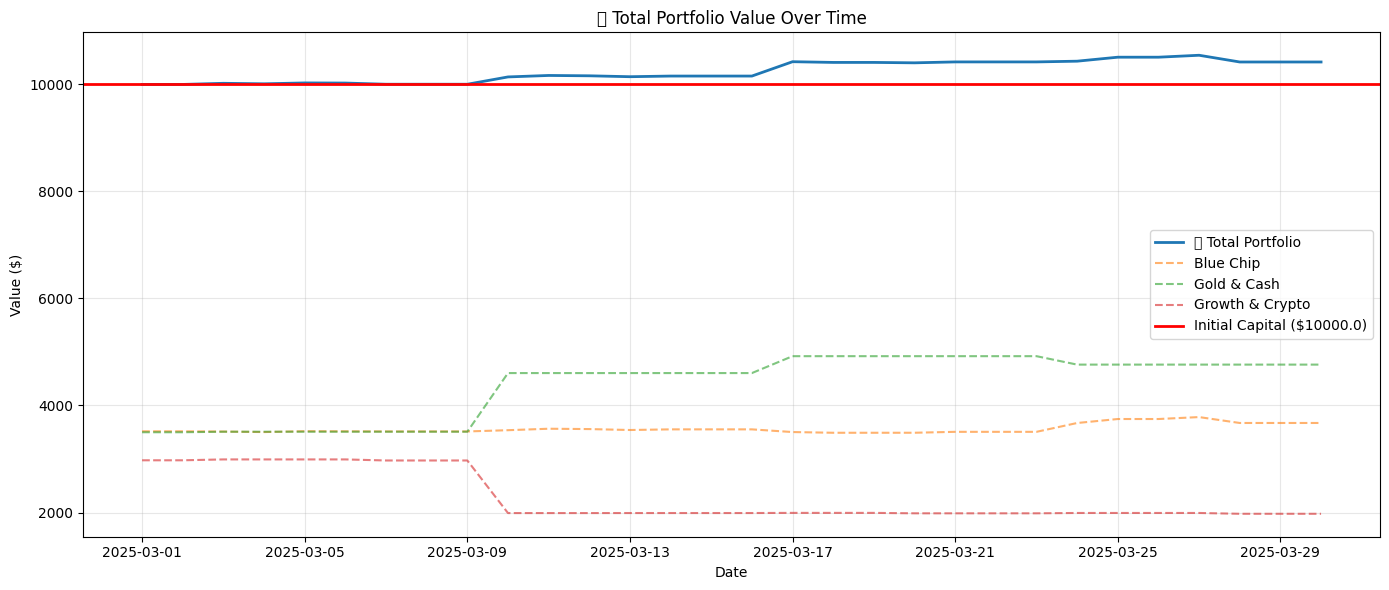

In [59]:
# ============================================
# COMBINE ALL COMPONENTS: BLUE CHIP + GOLD/CASH + GROWTH/CRYPTO
# ============================================

# Merge all 3 dataframes on Date
combined_df = pd.merge(
    blue_chip_day_to_day_df[['Date', 'Total_Blue_Chip_Value']],
    gold_cash_day_to_day_df[['Date', 'Total_Gold_Cash_Value']],
    on='Date',
    how='outer'
)

combined_df = pd.merge(
    combined_df,
    growth_day_to_day_df[['Date', 'Total_Growth_Crypto_Value']],
    on='Date',
    how='outer'
)

# Sort, filter from start_date, and fill missing values
combined_df = combined_df.sort_values(by='Date')
combined_df = combined_df[combined_df['Date'] >= start_date]  # ✅ Keep only user-defined window
combined_df = combined_df.ffill().dropna()

# Calculate total portfolio value
combined_df['Total_Portfolio_Value'] = (
    combined_df['Total_Blue_Chip_Value'] +
    combined_df['Total_Gold_Cash_Value'] +
    combined_df['Total_Growth_Crypto_Value']
)

# Display combined table
display(combined_df)

# ============================================
# PLOT TOTAL PORTFOLIO VALUE OVER TIME
# ============================================

plt.figure(figsize=(14, 6))
plt.plot(combined_df['Date'], combined_df['Total_Portfolio_Value'], label='💼 Total Portfolio', linewidth=2)
plt.plot(combined_df['Date'], combined_df['Total_Blue_Chip_Value'], '--', label='Blue Chip', alpha=0.6)
plt.plot(combined_df['Date'], combined_df['Total_Gold_Cash_Value'], '--', label='Gold & Cash', alpha=0.6)
plt.plot(combined_df['Date'], combined_df['Total_Growth_Crypto_Value'], '--', label='Growth & Crypto', alpha=0.6)

# Assuming initial capital is stored in capital_input.value
initial_capital = capital_input.value
plt.axhline(
    y=initial_capital,
    color='red',
    linestyle='-',
    linewidth=2,
    label='Initial Capital (${})'.format(initial_capital)
)

plt.title('📊 Total Portfolio Value Over Time')
plt.xlabel('Date')
plt.ylabel('Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


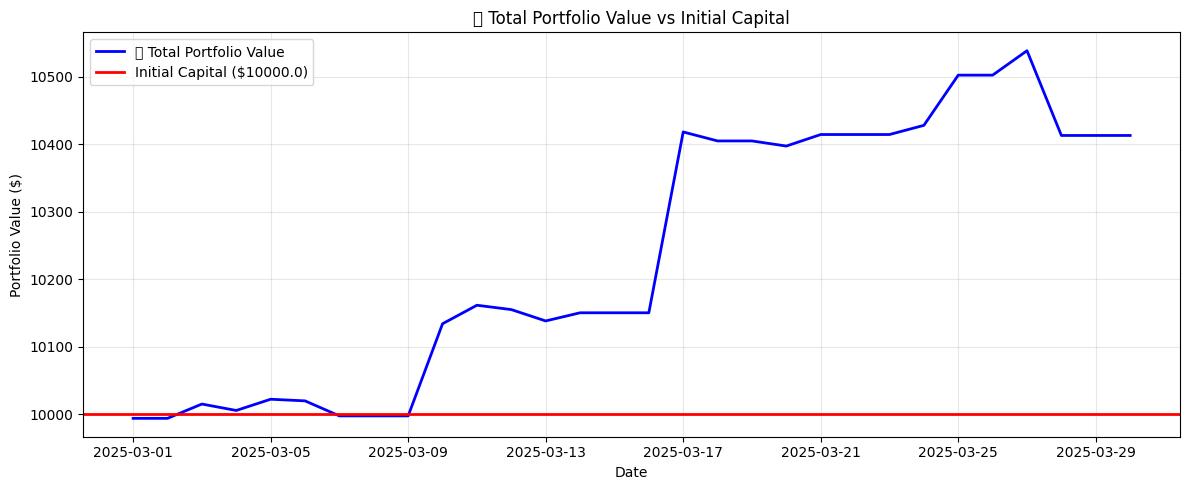

In [60]:
combined_df = combined_df[combined_df['Date'] >= start_date]

plt.figure(figsize=(12, 5))

# Plot only portfolio value
plt.plot(combined_df['Date'], combined_df['Total_Portfolio_Value'],
         label='💼 Total Portfolio Value', color='blue', linewidth=2)

# Plot initial capital as solid red line
plt.axhline(y=initial_capital, color='red', linestyle='-', linewidth=2,
            label='Initial Capital (${})'.format(initial_capital))

# Decorations
plt.title('📊 Total Portfolio Value vs Initial Capital')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Evaluation**

In [61]:
# Use Week column from one of the original DFs
combined_df['Week'] = pd.to_datetime(blue_chip_day_to_day_df.set_index('Date').loc[combined_df['Date']]['Week'].values)

# Map capital allocated from each component
combined_df['Allocated_BlueChip'] = combined_df['Week'].map(
    blue_chip_results.set_index('date')['capital_allocated']
)
combined_df['Allocated_GoldCash'] = combined_df['Week'].map(
    gold_cash_results.set_index('date')['capital_allocated']
)
combined_df['Allocated_Growth'] = combined_df['Week'].map(
    growth_results.set_index('date')['Capital_Allocated']
)

# Total capital allocated to portfolio each day
combined_df['Total_Allocated'] = (
    combined_df['Allocated_BlueChip'] +
    combined_df['Allocated_GoldCash'] +
    combined_df['Allocated_Growth']
)


In [62]:
portfolio_df_total = combined_df.set_index('Date')[['Total_Portfolio_Value', 'Total_Allocated']]
portfolio_df_total = portfolio_df_total.rename(columns={
    'Total_Portfolio_Value': 'Portfolio_Value',
    'Total_Allocated': 'Weekly_Allocation'
})


In [63]:
# Placeholder for trades, since we're not evaluating trade-level metrics
dummy_trade_log = pd.DataFrame(columns=['Entry_Date', 'Exit_Date', 'Profit'])

# Compute portfolio-level metrics
metrics_portfolio = compute_performance_metrics_dynamic(
    portfolio_df_total,
    dummy_trade_log,
    capital_column='Weekly_Allocation'
)

# Keep only high-level performance metrics
metrics_portfolio_filtered = {
    key: val for key, val in metrics_portfolio.items()
    if key in [
        'Annual Return (%)',
        'Annual Volatility (%)',
        'Sharpe Ratio',
        'Max Drawdown (%)',
        'Drawdown Events'
    ]
}

# Format for display
metrics_portfolio_df = pd.DataFrame(metrics_portfolio_filtered.items(), columns=["Metric", "Value"])
metrics_portfolio_df["Value"] = metrics_portfolio_df["Value"].apply(lambda x: round(x, 2) if isinstance(x, float) else x)

# Output
print("📊 Overall Portfolio Performance Metrics")
print(metrics_portfolio_df.to_string(index=False))


📊 Overall Portfolio Performance Metrics
               Metric  Value
    Annual Return (%)   7.33
Annual Volatility (%)   9.77
         Sharpe Ratio   0.75
     Max Drawdown (%)  -1.19
      Drawdown Events   5.00


In [64]:
all_trades_df

,Date,Sell Date,Stock,Stock Code,Buy Price,Sell Price,Confidence,Shares,Capital Allocated,Profit %,Profit ($),Trade_Week
0,2025-02-24,2025-03-04,Nike Inc,NKE,79.96,77.24,0.5001,3.5044,280.20,-3.39,-9.51,2025-02-24
1,2025-02-24,2025-03-03,Caterpillar Inc,CAT,339.26,331.71,0.5220,0.9841,333.87,-2.23,-7.43,2025-02-24
2,2025-02-24,2025-02-28,Apple Inc,AAPL,247.35,241.60,0.5250,1.3794,341.19,-2.32,-7.93,2025-02-24
3,2025-02-24,2025-03-03,Johnson & Johnson,JNJ,163.90,167.11,0.5101,1.8588,304.66,1.96,5.96,2025-02-24
4,2025-02-24,2025-02-28,Travelers Companies Inc,TRV,247.48,257.18,0.5018,1.1496,284.49,3.92,11.15,2025-02-24
...,...,...,...,...,...,...,...,...,...,...,...,...
95,2025-03-24,2025-03-27,Cisco Systems,CSCO,60.63,60.93,0.5184,5.4470,330.23,0.50,1.66,2025-03-24
96,2025-03-24,2025-03-27,Visa Inc,V,344.21,349.51,0.5155,0.9377,322.79,1.54,4.97,2025-03-24
97,2025-03-24,2025-03-28,Coca-Cola Co,KO,69.02,70.30,0.5627,6.3810,440.41,1.86,8.17,2025-03-24
98,2025-03-24,2025-03-28,Travelers Companies Inc,TRV,259.70,261.53,0.5099,1.1901,309.07,0.70,2.18,2025-03-24


In [65]:
g_all_trades_df

,Date,Asset,Action,Price,Size,Fee,Capital_After_Trade,Entry_Price,Momentum,P/L,Trade_Week
0,2025-02-25,PYPL,Buy,74.070000,11.290012,0.836251,2162.912551,74.070000,0.006131,NaN,2025-02-24
1,2025-02-26,PYPL,Sell,72.050003,11.290012,0.813445,2975.544517,74.070000,NaN,-23.619232,2025-02-24
2,2025-03-06,XRP,Buy,2.601729,89.409915,0.232620,2759.810373,2.601729,0.005315,NaN,2025-03-03
3,2025-03-07,XRP,Sell,2.381624,89.409915,0.212941,2972.538230,2.601729,NaN,-19.892504,2025-03-03
4,2025-03-12,XRP,Buy,2.240755,79.212666,0.177496,1813.410198,2.240755,0.003526,NaN,2025-03-10
5,2025-03-13,XRP,Sell,2.251008,79.212666,0.178308,1991.540238,2.240755,NaN,0.633855,2025-03-10
6,2025-03-13,PYPL,Buy,66.910004,8.166379,0.546412,1444.581408,66.910004,0.004062,NaN,2025-03-10
7,2025-03-19,XRP,Buy,2.545841,68.964114,0.175572,1818.650499,2.545841,0.021201,NaN,2025-03-17
8,2025-03-20,XRP,Sell,2.434674,68.964114,0.167905,1986.387732,2.545841,NaN,-7.834436,2025-03-17
9,2025-03-26,TSLA,Buy,272.059998,0.601674,0.163691,1828.940594,272.059998,0.004965,NaN,2025-03-24


In [66]:
gold_cash_log_df

,Entry_Date,Exit_Date,Asset,Entry_Price,Exit_Price,Confidence,Units,Capital Allocated,Profit (%),Profit,Trade_Week,Holding_Period
0,2025-02-24,2025-03-03,Gold,2947.90,2890.20,0.6857,0.441062,1301.51,-1.96,-28.02,2025-02-24,7
1,2025-03-03,2025-03-10,Gold,2890.20,2891.00,0.7618,0.628946,1819.60,0.03,-3.13,2025-03-03,7
2,2025-03-10,2025-03-17,Gold,2891.00,3000.00,0.7723,0.653437,1890.98,3.77,67.38,2025-03-10,7
3,2025-03-17,2025-03-24,USD,103.37,104.26,0.5196,1.341239,138.78,0.86,0.92,2025-03-17,7
4,2025-03-17,2025-03-24,Gold,3000.00,3013.10,0.7846,0.644687,1935.99,0.44,4.57,2025-03-17,7
5,2025-03-24,2025-03-31,Gold,3013.10,3122.80,0.7739,0.643808,1941.80,3.64,66.68,2025-03-24,7
6,2025-03-03,2025-03-10,Gold,2890.20,2891.00,0.7618,0.640894,1854.16,0.03,-3.19,2025-03-03,7
7,2025-03-10,2025-03-17,Gold,2891.00,3000.00,0.7723,0.665851,1926.90,3.77,68.66,2025-03-10,7
8,2025-03-17,2025-03-24,USD,103.37,104.26,0.5196,1.366718,141.42,0.86,0.93,2025-03-17,7
9,2025-03-17,2025-03-24,Gold,3000.00,3013.10,0.7846,0.656933,1972.77,0.44,4.66,2025-03-17,7


In [67]:
# Standardize Blue Chip log
blue_chip_log_df = all_trades_df.rename(columns={
    'Date': 'Entry_Date',
    'Sell Date': 'Exit_Date',
    'Buy Price': 'Entry_Price',
    'Sell Price': 'Exit_Price',
    'Profit ($)': 'Profit',
    'Stock': 'Asset'  # ✅ Fix: map 'Stock' → 'Asset'
})

# Trim to standard columns
blue_chip_log_df = blue_chip_log_df[['Entry_Date', 'Exit_Date', 'Asset', 'Entry_Price', 'Exit_Price', 'Profit']]

# Standardize Gold & Cash log (already correct format — just trim to relevant columns)
gold_cash_log_df = gold_cash_log_df[['Entry_Date', 'Exit_Date', 'Asset', 'Entry_Price', 'Exit_Price', 'Profit']]

# Standardize Growth/Crypto log
growth_log_df = g_all_trades_df.copy()

# Extract buy/sell pairs and compute profit
sells = growth_log_df[growth_log_df['Action'] == 'Sell'].copy()
sells['Entry_Date'] = pd.NaT
sells['Entry_Price'] = np.nan

# Match each Sell to the first Buy in the same week (FIFO)
for i, sell_row in sells.iterrows():
    matching_buys = growth_log_df[
        (growth_log_df['Action'] == 'Buy') &
        (growth_log_df['Asset'] == sell_row['Asset']) &
        (growth_log_df['Trade_Week'] == sell_row['Trade_Week'])
    ]
    if not matching_buys.empty:
        entry = matching_buys.iloc[0]
        sells.at[i, 'Entry_Date'] = entry['Date']
        sells.at[i, 'Entry_Price'] = entry['Price']
        sells.at[i, 'Exit_Date'] = sell_row['Date']
        sells.at[i, 'Exit_Price'] = sell_row['Price']
        sells.at[i, 'Profit'] = (sell_row['Price'] - entry['Price']) * sell_row['Size']

growth_log_df = sells.dropna(subset=['Entry_Date', 'Exit_Date', 'Profit'])

# Rename columns to match schema
growth_log_df = growth_log_df.rename(columns={
    'Exit_Date': 'Exit_Date',
    'Entry_Date': 'Entry_Date',
    'Entry_Price': 'Entry_Price',
    'Exit_Price': 'Exit_Price'
})

# Select only the needed columns
growth_log_df = growth_log_df[['Entry_Date', 'Exit_Date', 'Asset', 'Entry_Price', 'Exit_Price', 'Profit']]

# Ensure datetime types
for df_ in [blue_chip_log_df, gold_cash_log_df, growth_log_df]:
    df_['Entry_Date'] = pd.to_datetime(df_['Entry_Date'])
    df_['Exit_Date'] = pd.to_datetime(df_['Exit_Date'])

# ✅ Combine all logs into one
combined_trade_log = pd.concat(
    [blue_chip_log_df, gold_cash_log_df, growth_log_df],
    ignore_index=True
)


In [68]:
metrics_portfolio = compute_performance_metrics_dynamic(
    portfolio_df_total,
    combined_trade_log,
    capital_column='Weekly_Allocation'
)

metrics_portfolio_df = pd.DataFrame(metrics_portfolio.items(), columns=["Metric", "Value"])
metrics_portfolio_df["Value"] = metrics_portfolio_df["Value"].apply(lambda x: round(x, 2) if isinstance(x, float) else x)

print("📊 Overall Portfolio Performance Metrics (with Trade Stats)")
print(metrics_portfolio_df.to_string(index=False))


📊 Overall Portfolio Performance Metrics (with Trade Stats)
                       Metric  Value
            Annual Return (%)   7.33
        Annual Volatility (%)   9.77
                 Sharpe Ratio   0.75
             Max Drawdown (%)  -1.19
              Drawdown Events   5.00
             Number of Trades 125.00
                 Win Rate (%)  59.20
Average Holding Period (days)   5.89
             Profit per Trade   5.64
